# Notebook 4 — Multi-Temporal Landsat Data Preparation for LULC Analysis

## Objective

This notebook prepares multi-temporal Landsat imagery for Land Use/Land Cover (LULC) analysis within the established Gomti River–Lucknow study area.

Three Landsat observation years are used:

- **2003** — Landsat 7 ETM+
- **2014** — Landsat 8 OLI
- **2025** — Landsat 8/9 OLI

The imagery is used to investigate changes in land-cover conditions across the study period and to subsequently derive LULC-related variables for the flood-susceptibility analysis.

---

## Why These Three Years?

The study uses approximately decadal temporal intervals to examine long-term land-cover change:

**2003 → 2014 → 2025**

The 2003 imagery is from Landsat 7 ETM+ and the later observations are from the Landsat 8/9 OLI generation. Although the sensors differ, the imagery will be processed using a consistent workflow and the appropriate spectral bands for each sensor.

The selected scenes use the same WRS Path/Row:

**Path 144 / Row 041**

This provides a consistent spatial framework for the three temporal observations.

---

## Data Source

The Landsat imagery is obtained from the **USGS Landsat Collection 2 Level-2** products.

Level-2 products provide atmospherically corrected surface reflectance data and, where available, surface-temperature products. For this notebook, the surface-reflectance bands and quality-assurance layers are the primary inputs for LULC-related analysis.

---

## Dataset Organization

The raw Landsat datasets are stored separately by observation year:

```text
data/
└── raw/
    ├── 2003/
    │   └── Landsat 7 ETM+ scene
    │
    ├── 2014/
    │   └── Landsat 8 OLI scene
    │
    └── 2025/
        └── Landsat 8/9 OLI scene

## 1. Landsat Band Identification

The downloaded Landsat Collection 2 Level-2 products contain individual
GeoTIFF files for the spectral bands and quality-assurance layers.

Only the bands required for the LULC analysis are selected.

Because Landsat 7 ETM+ and Landsat 8/9 OLI use different band numbering,
the physical spectral role of each band is used when constructing the
multi-temporal dataset.

### Landsat 7 ETM+ — 2003

- Blue → B1
- Green → B2
- Red → B3
- NIR → B4
- SWIR 1 → B5
- SWIR 2 → B7

### Landsat 8/9 OLI — 2014 and 2025

- Blue → B2
- Green → B3
- Red → B4
- NIR → B5
- SWIR 1 → B6
- SWIR 2 → B7

The QA layers are retained for quality-control and cloud/shadow masking.

In [73]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

RAW_LANDSAT_DIR = PROJECT_ROOT / "data" / "raw"

years = [2003, 2014, 2025]

for year in years:

    year_dir = RAW_LANDSAT_DIR / str(year)

    print("\n" + "=" * 70)
    print(f"{year} LANDSAT FILES")
    print("=" * 70)

    for file in sorted(year_dir.rglob("*")):
        if file.is_file():
            print(file.name)


2003 LANDSAT FILES
LE07_L2SP_144041_20030221_20200916_02_T1_ANG.txt
LE07_L2SP_144041_20030221_20200916_02_T1_MTL.json
LE07_L2SP_144041_20030221_20200916_02_T1_MTL.txt
LE07_L2SP_144041_20030221_20200916_02_T1_MTL.xml
LE07_L2SP_144041_20030221_20200916_02_T1_QA_PIXEL.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_QA_RADSAT.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_ATMOS_OPACITY.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B1.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B1.TIF.aux.xml
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B2.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B2.TIF.aux.xml
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B3.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B3.TIF.aux.xml
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B4.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B4.TIF.aux.xml
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B5.TIF
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B5.TIF.aux.xml
LE07_L2SP_144041_20030221_20200916_02_T1_SR_B7.TIF
LE07_L2SP_1

## 2. Surface Reflectance Scaling and Quality Masking

The downloaded Landsat Collection 2 Level-2 surface-reflectance bands contain
scaled digital values rather than direct surface-reflectance values.

The Landsat Collection 2 scale factor and offset are therefore applied before
using the spectral bands for analysis.

Quality-assurance (QA) information is also used to identify pixels affected
by conditions such as:

- Cloud
- Cloud shadow
- Cirrus
- Snow/ice
- Other invalid observations

These pixels are excluded from the analysis.

The masking procedure is sensor-independent at the conceptual level, but the
actual Landsat QA bit structure is applied according to the corresponding
Collection 2 product.

The result is a quality-controlled surface-reflectance dataset suitable for
spectral-index calculation and subsequent LULC analysis.

In [74]:
from pathlib import Path
import rasterio
import numpy as np

# Raw Landsat directories
landsat_dirs = {
    2003: RAW_LANDSAT_DIR / "2003",
    2014: RAW_LANDSAT_DIR / "2014",
    2025: RAW_LANDSAT_DIR / "2025"
}

# Sensor-specific spectral bands
landsat_bands = {
    2003: {
        "blue": "SR_B1",
        "green": "SR_B2",
        "red": "SR_B3",
        "nir": "SR_B4",
        "swir1": "SR_B5",
        "swir2": "SR_B7"
    },
    2014: {
        "blue": "SR_B2",
        "green": "SR_B3",
        "red": "SR_B4",
        "nir": "SR_B5",
        "swir1": "SR_B6",
        "swir2": "SR_B7"
    },
    2025: {
        "blue": "SR_B2",
        "green": "SR_B3",
        "red": "SR_B4",
        "nir": "SR_B5",
        "swir1": "SR_B6",
        "swir2": "SR_B7"
    }
}

for year, bands in landsat_bands.items():

    print(f"\n{year}")
    print("-" * 40)

    for name, band in bands.items():
        print(f"{name:8s} → {band}")


2003
----------------------------------------
blue     → SR_B1
green    → SR_B2
red      → SR_B3
nir      → SR_B4
swir1    → SR_B5
swir2    → SR_B7

2014
----------------------------------------
blue     → SR_B2
green    → SR_B3
red      → SR_B4
nir      → SR_B5
swir1    → SR_B6
swir2    → SR_B7

2025
----------------------------------------
blue     → SR_B2
green    → SR_B3
red      → SR_B4
nir      → SR_B5
swir1    → SR_B6
swir2    → SR_B7


In [75]:
def find_landsat_file(year, band_name):
    """
    Find a Landsat surface-reflectance band inside the
    corresponding year directory.
    """

    year_dir = landsat_dirs[year]

    matches = list(
        year_dir.rglob(f"*_{band_name}.TIF")
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No {band_name} file found for {year}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple {band_name} files found for {year}:\n"
            + "\n".join(str(x) for x in matches)
        )

    return matches[0]


# Find all required spectral bands
band_files = {}

for year, bands in landsat_bands.items():

    band_files[year] = {}

    for name, band in bands.items():

        band_files[year][name] = find_landsat_file(
            year,
            band
        )

print("Required Landsat bands located successfully.")

Required Landsat bands located successfully.


In [76]:
for year in band_files:

    print(f"\n{year}")

    for name, path in band_files[year].items():
        print(f"{name:8s}: {path.name}")


2003
blue    : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B1.TIF
green   : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B2.TIF
red     : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B3.TIF
nir     : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B4.TIF
swir1   : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B5.TIF
swir2   : LE07_L2SP_144041_20030221_20200916_02_T1_SR_B7.TIF

2014
blue    : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B2.TIF
green   : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B3.TIF
red     : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B4.TIF
nir     : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B5.TIF
swir1   : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B6.TIF
swir2   : LC08_L2SP_144041_20140211_20200911_02_T1_SR_B7.TIF

2025
blue    : LC08_L2SP_144041_20250225_20250304_02_T1_SR_B2.TIF
green   : LC08_L2SP_144041_20250225_20250304_02_T1_SR_B3.TIF
red     : LC08_L2SP_144041_20250225_20250304_02_T1_SR_B4.TIF
nir     : LC08_L2SP_144041_20250225_20250304_02_T1_SR_B5.TIF
swir1 

In [77]:
def find_qa_pixel(year):

    year_dir = landsat_dirs[year]

    matches = list(
        year_dir.rglob("*_QA_PIXEL.TIF")
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"QA_PIXEL file not found for {year}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple QA_PIXEL files found for {year}"
        )

    return matches[0]


qa_pixel_files = {
    year: find_qa_pixel(year)
    for year in years
}

for year, path in qa_pixel_files.items():

    print(
        f"{year}: {path.name}"
    )

2003: LE07_L2SP_144041_20030221_20200916_02_T1_QA_PIXEL.TIF
2014: LC08_L2SP_144041_20140211_20200911_02_T1_QA_PIXEL.TIF
2025: LC08_L2SP_144041_20250225_20250304_02_T1_QA_PIXEL.TIF


In [78]:
def create_qa_mask(qa_array):
    """
    Create a valid-pixel mask from Landsat Collection 2 QA_PIXEL.

    True  = usable pixel
    False = pixel excluded from analysis
    """

    # QA_PIXEL bit positions
    fill = (qa_array & (1 << 0)) != 0
    dilated_cloud = (qa_array & (1 << 1)) != 0
    cirrus = (qa_array & (1 << 2)) != 0
    cloud = (qa_array & (1 << 3)) != 0
    cloud_shadow = (qa_array & (1 << 4)) != 0
    snow = (qa_array & (1 << 5)) != 0

    invalid = (
        fill
        | dilated_cloud
        | cirrus
        | cloud
        | cloud_shadow
        | snow
    )

    valid = ~invalid

    return valid

In [79]:
for year in years:

    with rasterio.open(qa_pixel_files[year]) as src:

        qa = src.read(1)

        valid_mask = create_qa_mask(qa)

        total_pixels = valid_mask.size
        valid_pixels = np.count_nonzero(valid_mask)
        invalid_pixels = total_pixels - valid_pixels

        valid_percent = (
            valid_pixels / total_pixels
        ) * 100

        invalid_percent = (
            invalid_pixels / total_pixels
        ) * 100

    print(f"\n{year}")
    print("-" * 40)
    print(f"Total pixels:   {total_pixels:,}")
    print(f"Valid pixels:   {valid_pixels:,}")
    print(f"Invalid pixels: {invalid_pixels:,}")
    print(f"Valid:          {valid_percent:.2f}%")
    print(f"Invalid:        {invalid_percent:.2f}%")


2003
----------------------------------------
Total pixels:   55,899,571
Valid pixels:   37,877,562
Invalid pixels: 18,022,009
Valid:          67.76%
Invalid:        32.24%

2014
----------------------------------------
Total pixels:   59,685,451
Valid pixels:   38,158,052
Invalid pixels: 21,527,399
Valid:          63.93%
Invalid:        36.07%

2025
----------------------------------------
Total pixels:   59,685,451
Valid pixels:   39,703,723
Invalid pixels: 19,981,728
Valid:          66.52%
Invalid:        33.48%


### QA Mask Diagnostic

The initial QA mask excludes pixels flagged by the Landsat Collection 2
QA_PIXEL layer.

The proportion of excluded pixels is relatively large despite the selected
scenes having low reported cloud cover. Therefore, the individual QA flags
are examined before finalizing the masking rule.

This diagnostic is performed to distinguish actual atmospheric contamination
from other QA conditions that may be present outside the study area.

The final mask will be selected based on the QA flags relevant to the LULC
analysis.

In [80]:
def qa_flag_counts(qa_array):

    flags = {
        "Fill":        (qa_array & (1 << 0)) != 0,
        "Dilated cloud": (qa_array & (1 << 1)) != 0,
        "Cirrus":      (qa_array & (1 << 2)) != 0,
        "Cloud":       (qa_array & (1 << 3)) != 0,
        "Cloud shadow": (qa_array & (1 << 4)) != 0,
        "Snow/Ice":    (qa_array & (1 << 5)) != 0
    }

    return {
        name: np.count_nonzero(mask)
        for name, mask in flags.items()
    }


for year in years:

    with rasterio.open(qa_pixel_files[year]) as src:
        qa = src.read(1)

    counts = qa_flag_counts(qa)

    print("\n" + "=" * 50)
    print(year)
    print("=" * 50)

    for flag, count in counts.items():
        print(f"{flag:16s}: {count:,}")


2003
Fill            : 17,985,701
Dilated cloud   : 17,094
Cirrus          : 0
Cloud           : 10,184
Cloud shadow    : 16,178
Snow/Ice        : 0

2014
Fill            : 19,170,146
Dilated cloud   : 420,663
Cirrus          : 633,039
Cloud           : 1,161,808
Cloud shadow    : 977,394
Snow/Ice        : 58

2025
Fill            : 19,154,076
Dilated cloud   : 279,709
Cirrus          : 61,905
Cloud           : 438,633
Cloud shadow    : 199,279
Snow/Ice        : 0


### QA Coverage Within the Study Area

The initial QA diagnostic was calculated for the complete Landsat scenes.
Because the analysis is restricted to the established study area, the
proportion of valid and invalid pixels is recalculated only within that
area.

This provides the relevant measure of image usability for the subsequent
LULC analysis.

In [81]:
import rasterio.mask

In [82]:
import geopandas as gpd
# Use the existing study-area geometry.
# Reproject it to each Landsat raster CRS before masking.
study_area = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

vector_extensions = {
    ".shp", ".gpkg", ".geojson", ".json", ".kml"
}

if study_area.is_file():
    study_area_path = study_area
elif study_area.is_dir():
    candidates = [
        path for path in study_area.rglob("*")
        if path.is_file() and path.suffix.lower() in vector_extensions
    ]

    if not candidates:
        raise FileNotFoundError(
            f"No vector study-area file found in: {study_area}"
        )

    study_area_path = candidates[0]
else:
    candidates = [
        path for path in study_area.parent.glob(f"{study_area.name}.*")
        if path.is_file() and path.suffix.lower() in vector_extensions
    ]

    if not candidates:
        raise FileNotFoundError(
            f"Study-area vector file not found: {study_area}"
        )

    study_area_path = candidates[0]

study_area_vector = gpd.read_file(study_area_path)

if study_area_vector.crs is None:
    study_area_vector = study_area_vector.set_crs("EPSG:32644")

for year in years:

    with rasterio.open(qa_pixel_files[year]) as src:

        if src.crs is None:
            raise ValueError(
                f"QA raster has no CRS: {qa_pixel_files[year]}"
            )

        study_area_raster_crs = study_area_vector.to_crs(src.crs)

        geometries = [
            geometry.__geo_interface__
            for geometry in study_area_raster_crs.geometry
            if geometry is not None and not geometry.is_empty
        ]

        if not geometries:
            raise ValueError(
                f"Study-area geometry is empty: {study_area_path}"
            )

        qa_clipped, _ = rasterio.mask.mask(
            src,
            geometries,
            crop=True,
            filled=False
        )

        qa = qa_clipped[0]
        valid_data = ~qa.mask
        qa_values = qa.data
        valid_mask = create_qa_mask(qa_values)

        # Only consider pixels that are actually inside the study area.
        valid_mask &= valid_data

        study_pixels = np.count_nonzero(valid_data)
        usable_pixels = np.count_nonzero(valid_mask)
        unusable_pixels = study_pixels - usable_pixels

        if study_pixels == 0:
            raise ValueError(
                f"Study area does not overlap the {year} QA raster."
            )

        usable_percent = (usable_pixels / study_pixels) * 100
        unusable_percent = (unusable_pixels / study_pixels) * 100

    print("\n" + "=" * 55)
    print(f"{year} - QA COVERAGE WITHIN STUDY AREA")
    print("=" * 55)

    print(f"Study-area pixels: {study_pixels:,}")
    print(f"Usable pixels:     {usable_pixels:,}")
    print(f"Unusable pixels:   {unusable_pixels:,}")
    print(f"Usable:            {usable_percent:.2f}%")
    print(f"Unusable:          {unusable_percent:.2f}%")


2003 - QA COVERAGE WITHIN STUDY AREA
Study-area pixels: 3,314,354
Usable pixels:     3,306,529
Unusable pixels:   7,825
Usable:            99.76%
Unusable:          0.24%

2014 - QA COVERAGE WITHIN STUDY AREA
Study-area pixels: 3,314,354
Usable pixels:     3,205,084
Unusable pixels:   109,270
Usable:            96.70%
Unusable:          3.30%

2025 - QA COVERAGE WITHIN STUDY AREA
Study-area pixels: 3,314,354
Usable pixels:     2,909,196
Unusable pixels:   405,158
Usable:            87.78%
Unusable:          12.22%


### QA Flag Diagnostic Within the Study Area

The 2025 scene contains a higher proportion of QA-excluded pixels within
the study area than the 2003 and 2014 observations.

The individual QA flags are therefore examined specifically within the
study area to determine whether the excluded pixels are primarily caused
by cloud-related contamination or by other invalid-data conditions.

This diagnostic will determine whether the current QA mask can be retained
for the 2025 observation or whether the scene requires further treatment.

In [83]:
def qa_flag_counts_within_study_area(year):

    with rasterio.open(qa_pixel_files[year]) as src:

        study_area_raster = study_area_vector.to_crs(src.crs)

        geometries = [
            geom.__geo_interface__
            for geom in study_area_raster.geometry
            if geom is not None and not geom.is_empty
        ]

        if not geometries:
            raise ValueError(
                f"Study-area geometry is empty: {study_area_path}"
            )

        qa_clipped, _ = rasterio.mask.mask(
            src,
            geometries,
            crop=True,
            filled=False
        )

        qa = qa_clipped[0]

        inside = ~qa.mask
        qa_values = qa.data

        flags = {
            "Fill": (qa_values & (1 << 0)) != 0,
            "Dilated cloud": (qa_values & (1 << 1)) != 0,
            "Cirrus": (qa_values & (1 << 2)) != 0,
            "Cloud": (qa_values & (1 << 3)) != 0,
            "Cloud shadow": (qa_values & (1 << 4)) != 0,
            "Snow/Ice": (qa_values & (1 << 5)) != 0
        }

        counts = {}

        for name, flag in flags.items():
            counts[name] = np.count_nonzero(
                flag & inside
            )

        total_inside = np.count_nonzero(inside)

    return counts, total_inside


for year in years:

    counts, total_inside = (
        qa_flag_counts_within_study_area(year)
    )

    print("\n" + "=" * 60)
    print(f"{year} - QA FLAGS WITHIN STUDY AREA")
    print("=" * 60)

    for name, count in counts.items():

        percentage = (
            count / total_inside
        ) * 100

        print(
            f"{name:16s}: "
            f"{count:,} "
            f"({percentage:.2f}%)"
        )


2003 - QA FLAGS WITHIN STUDY AREA
Fill            : 6,505 (0.20%)
Dilated cloud   : 494 (0.01%)
Cirrus          : 0 (0.00%)
Cloud           : 230 (0.01%)
Cloud shadow    : 620 (0.02%)
Snow/Ice        : 0 (0.00%)

2014 - QA FLAGS WITHIN STUDY AREA
Fill            : 0 (0.00%)
Dilated cloud   : 21,635 (0.65%)
Cirrus          : 32,498 (0.98%)
Cloud           : 45,087 (1.36%)
Cloud shadow    : 48,910 (1.48%)
Snow/Ice        : 0 (0.00%)

2025 - QA FLAGS WITHIN STUDY AREA
Fill            : 0 (0.00%)
Dilated cloud   : 97,143 (2.93%)
Cirrus          : 59,721 (1.80%)
Cloud           : 285,899 (8.63%)
Cloud shadow    : 40,979 (1.24%)
Snow/Ice        : 0 (0.00%)


## 2. QA Masking — Result

The Landsat Collection 2 QA_PIXEL layer was used to exclude pixels affected
by invalid observations, clouds, cloud shadows, cirrus, and related quality
flags.

After restricting the assessment to the established study area:

| Year | Usable pixels | Unusable pixels |
|------|---------------:|----------------:|
| 2003 | 99.76% | 0.24% |
| 2014 | 96.70% | 3.30% |
| 2025 | 87.78% | 12.22% |

The 2003 and 2014 observations provide high usable coverage.

The 2025 observation contains substantially more cloud-related masking,
with cloud flags accounting for approximately 8.63% of the study-area
pixels, in addition to cirrus and cloud-shadow flags.

The QA mask is therefore retained without relaxing the quality criteria.
Cloud-contaminated pixels will remain excluded rather than being treated
as valid land-cover observations.

The 2025 scene will be retained for subsequent processing, with its
remaining valid pixels used for the LULC analysis.

## 3. Surface Reflectance Scaling

Landsat Collection 2 Level-2 surface-reflectance bands are stored as
scaled integer values.

The Collection 2 surface-reflectance scale factor and additive offset are
applied to convert the stored values into surface-reflectance values:

\[
SR = DN \times 0.0000275 - 0.2
\]

The transformation is applied consistently to the selected spectral bands
for 2003, 2014, and 2025.

Pixels excluded by the QA mask are assigned NoData values and are not used
in subsequent spectral-index calculations or LULC classification.

In [84]:
# ============================================================
# Step 3A — Scale and QA-mask Landsat surface reflectance
# ============================================================

scaled_bands = {}

SCALE_FACTOR = 0.0000275
ADD_OFFSET = -0.2

for year in years:

    scaled_bands[year] = {}

    # --------------------------------------------------------
    # Read the QA layer
    # --------------------------------------------------------
    with rasterio.open(qa_pixel_files[year]) as qa_src:

        qa = qa_src.read(1)

    qa_mask = create_qa_mask(qa)

    # --------------------------------------------------------
    # Process each required spectral band
    # --------------------------------------------------------
    for band_name, band_path in band_files[year].items():

        with rasterio.open(band_path) as src:

            dn = src.read(1).astype("float32")

        # Convert stored DN to surface reflectance
        reflectance = (
            dn * SCALE_FACTOR
            + ADD_OFFSET
        )

        # Remove invalid QA pixels
        reflectance[~qa_mask] = np.nan

        # Also remove physically invalid reflectance values
        reflectance[
           (reflectance < 0) | (reflectance > 1)
        ] = np.nan

        scaled_bands[year][band_name] = reflectance
    print(
        f"{year}: spectral bands scaled and QA-masked."
    )

2003: spectral bands scaled and QA-masked.
2014: spectral bands scaled and QA-masked.
2025: spectral bands scaled and QA-masked.


In [85]:
print(type(scaled_bands))
print(scaled_bands.keys())

for year in scaled_bands:

    print(f"\n{year}")

    for band_name, array in scaled_bands[year].items():

        valid = np.isfinite(array)

        print(
            f"{band_name:8s} | "
            f"min={np.nanmin(array):.4f} | "
            f"max={np.nanmax(array):.4f} | "
            f"valid={np.count_nonzero(valid):,}"
        )

<class 'dict'>
dict_keys([2003, 2014, 2025])

2003
blue     | min=0.0002 | max=0.3499 | valid=37,877,296
green    | min=0.0144 | max=0.4293 | valid=37,877,562
red      | min=0.0058 | max=0.4802 | valid=37,877,562
nir      | min=0.0193 | max=0.5882 | valid=37,877,562
swir1    | min=0.0006 | max=0.9407 | valid=37,877,556
swir2    | min=0.0012 | max=0.9928 | valid=37,877,365

2014
blue     | min=0.0000 | max=0.4333 | valid=38,157,865
green    | min=0.0009 | max=0.5619 | valid=38,158,044
red      | min=0.0001 | max=0.6668 | valid=38,158,033
nir      | min=0.0001 | max=0.8224 | valid=38,158,044
swir1    | min=0.0000 | max=0.9921 | valid=38,157,965
swir2    | min=0.0000 | max=0.9914 | valid=38,157,757

2025
blue     | min=0.0005 | max=0.4789 | valid=39,703,717
green    | min=0.0189 | max=0.4140 | valid=39,703,723
red      | min=0.0061 | max=0.4613 | valid=39,703,723
nir      | min=0.0158 | max=0.6672 | valid=39,703,723
swir1    | min=0.0005 | max=0.9977 | valid=39,703,708
swir2    | min=0.00

## 4. Spectral Index Calculation

Spectral indices transform combinations of Landsat spectral bands into
quantitative indicators that help distinguish different land-cover
characteristics.

Three indices are calculated for each observation year:

### NDVI — Normalized Difference Vegetation Index

NDVI is used to identify and characterize vegetation.

\[
NDVI = \frac{NIR - Red}{NIR + Red}
\]

Higher NDVI values generally indicate stronger vegetation response.

### NDBI — Normalized Difference Built-up Index

NDBI is used to enhance built-up and impervious surfaces.

\[
NDBI = \frac{SWIR1 - NIR}{SWIR1 + NIR}
\]

Higher values generally indicate stronger built-up/impervious surface
response.

### MNDWI — Modified Normalized Difference Water Index

MNDWI is used to enhance open-water features.

\[
MNDWI = \frac{Green - SWIR1}{Green + SWIR1}
\]

Higher values generally indicate stronger water response.

The indices are calculated using the physically corresponding spectral
bands for each Landsat sensor rather than using identical band numbers
across sensors.

All calculations use the QA-masked surface-reflectance data produced in
Step 3.

In [86]:
# ============================================================
# Step 4 — Calculate NDVI, NDBI and MNDWI
# ============================================================

indices = {}

for year in years:

    # Get the scaled surface-reflectance bands
    bands = scaled_bands[year]

    blue = bands["blue"]
    green = bands["green"]
    red = bands["red"]
    nir = bands["nir"]
    swir1 = bands["swir1"]

    # --------------------------------------------------------
    # NDVI
    # --------------------------------------------------------
    ndvi_denominator = nir + red

    ndvi = np.full(
        nir.shape,
        np.nan,
        dtype="float32"
    )

    valid_ndvi = (
        np.isfinite(nir)
        & np.isfinite(red)
        & (ndvi_denominator != 0)
    )

    ndvi[valid_ndvi] = (
        (nir[valid_ndvi] - red[valid_ndvi])
        / ndvi_denominator[valid_ndvi]
    )

    # --------------------------------------------------------
    # NDBI
    # --------------------------------------------------------
    ndbi_denominator = swir1 + nir

    ndbi = np.full(
        nir.shape,
        np.nan,
        dtype="float32"
    )

    valid_ndbi = (
        np.isfinite(swir1)
        & np.isfinite(nir)
        & (ndbi_denominator != 0)
    )

    ndbi[valid_ndbi] = (
        (swir1[valid_ndbi] - nir[valid_ndbi])
        / ndbi_denominator[valid_ndbi]
    )

    # --------------------------------------------------------
    # MNDWI
    # --------------------------------------------------------
    mndwi_denominator = green + swir1

    mndwi = np.full(
        green.shape,
        np.nan,
        dtype="float32"
    )

    valid_mndwi = (
        np.isfinite(green)
        & np.isfinite(swir1)
        & (mndwi_denominator != 0)
    )

    mndwi[valid_mndwi] = (
        (green[valid_mndwi] - swir1[valid_mndwi])
        / mndwi_denominator[valid_mndwi]
    )

    # --------------------------------------------------------
    # IMPORTANT: actually store the results
    # --------------------------------------------------------
    indices[year] = {
        "NDVI": ndvi,
        "NDBI": ndbi,
        "MNDWI": mndwi
    }

    print(
        f"{year}: NDVI, NDBI and MNDWI calculated."
    )

2003: NDVI, NDBI and MNDWI calculated.
2014: NDVI, NDBI and MNDWI calculated.
2025: NDVI, NDBI and MNDWI calculated.


In [87]:
def normalized_difference(band_a, band_b):
    """
    Calculate a normalized difference index while
    avoiding division by zero.
    """
    
    denominator = band_a + band_b

    result = np.full(
        band_a.shape,
        np.nan,
        dtype="float32"
    )

    valid = (
        np.isfinite(band_a)
        & np.isfinite(band_b)
        & (denominator != 0)
    )

    result[valid] = (
        (band_a[valid] - band_b[valid])
        / denominator[valid]
    )

    return result

In [88]:
for year in years:

    print("\n" + "=" * 50)
    print(year)
    print("=" * 50)

    year_indices = indices.get(year)

    if year_indices is None:
        print(f"No calculated indices found for {year}.")
        continue

    for index_name, array in year_indices.items():

        valid = np.isfinite(array)

        if np.count_nonzero(valid) == 0:
            print(f"{index_name}: no valid pixels")
            continue

        print(
            f"{index_name}: "
            f"min={np.nanmin(array):.3f}, "
            f"max={np.nanmax(array):.3f}, "
            f"mean={np.nanmean(array):.3f}, "
            f"valid={np.count_nonzero(valid):,}"
        )


2003
NDVI: min=-0.542, max=0.942, mean=0.593, valid=37,877,562
NDBI: min=-0.991, max=0.536, mean=-0.227, valid=37,877,556
MNDWI: min=-0.796, max=0.990, mean=-0.410, valid=37,877,556

2014
NDVI: min=-0.996, max=0.998, mean=0.606, valid=38,158,025
NDBI: min=-1.000, max=0.953, mean=-0.231, valid=38,157,957
MNDWI: min=-0.991, max=1.000, mean=-0.385, valid=38,157,957

2025
NDVI: min=-0.507, max=0.944, mean=0.599, valid=39,703,723
NDBI: min=-0.980, max=0.738, mean=-0.258, valid=39,703,708
MNDWI: min=-0.884, max=0.979, mean=-0.376, valid=39,703,708


## 5. Save Spectral Indices

The calculated NDVI, NDBI, and MNDWI rasters are saved as GeoTIFF
products for each observation year.

The outputs retain the spatial reference, raster dimensions, and
georeferencing of the corresponding Landsat surface-reflectance data.

These index rasters will be used as input features for the subsequent
LULC classification and temporal land-cover analysis.

Output structure:

data/
└── processed/
    └── notebook_04/
        ├── 2003/
        ├── 2014/
        └── 2025/

In [89]:
from pathlib import Path

NOTEBOOK_04_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_04"
)

for year in years:
    (NOTEBOOK_04_DIR / str(year)).mkdir(
        parents=True,
        exist_ok=True
    )

print("Notebook 4 output directories ready.")

Notebook 4 output directories ready.


In [90]:
import rasterio

for year in years:

    # Use one original spectral band as the spatial reference
    reference_band = band_files[year]["red"]

    with rasterio.open(reference_band) as src:

        profile = src.profile.copy()

    # Store floating-point index values
    profile.update(
        dtype="float32",
        count=1,
        nodata=np.nan,
        compress="lzw"
    )

    for index_name, array in indices[year].items():

        output_path = (
            NOTEBOOK_04_DIR
            / str(year)
            / f"{index_name}_{year}.tif"
        )

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                array.astype("float32"),
                1
            )

        print(
            f"Saved: {output_path}"
        )

Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2003\NDVI_2003.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2003\NDBI_2003.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2003\MNDWI_2003.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2014\NDVI_2014.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2014\NDBI_2014.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2014\MNDWI_2014.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2025\NDVI_2025.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2025\NDBI_2025.tif
Saved: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\2025\MNDWI_2025.tif


In [91]:
for year in years:

    print(f"\n{year}")

    year_dir = NOTEBOOK_04_DIR / str(year)

    for file in sorted(year_dir.glob("*.tif")):
        print(file.name)


2003
MNDWI_2003.tif
NDBI_2003.tif
NDVI_2003.tif

2014
MNDWI_2014.tif
NDBI_2014.tif
NDVI_2014.tif

2025
MNDWI_2025.tif
NDBI_2025.tif
NDVI_2025.tif


## 6. LULC Feature Stack Preparation

The LULC classification requires multiple spectral and spectral-index
features rather than a single raster layer.

For each observation year, the following nine features are prepared:

### Spectral bands

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2

### Spectral indices

- NDVI
- NDBI
- MNDWI

The spectral bands provide the original multispectral information, while
the indices provide enhanced information related to vegetation, built-up
surfaces, and water.

The same feature structure is maintained across 2003, 2014, and 2025.
Sensor-specific band numbering has already been handled during the
previous processing steps.

These features will form the input variables for the subsequent LULC
classification.

In [92]:
# ============================================================
# Step 6A — Create LULC feature stacks
# ============================================================

feature_stacks = {}

feature_names = [
    "blue",
    "green",
    "red",
    "nir",
    "swir1",
    "swir2",
    "NDVI",
    "NDBI",
    "MNDWI"
]

for year in years:

    feature_stacks[year] = {}

    # Spectral bands
    for band_name in [
        "blue",
        "green",
        "red",
        "nir",
        "swir1",
        "swir2"
    ]:
        feature_stacks[year][band_name] = (
            scaled_bands[year][band_name]
        )

    # Spectral indices
    feature_stacks[year]["NDVI"] = (
        indices[year]["NDVI"]
    )

    feature_stacks[year]["NDBI"] = (
        indices[year]["NDBI"]
    )

    feature_stacks[year]["MNDWI"] = (
        indices[year]["MNDWI"]
    )

    print(
        f"{year}: {len(feature_stacks[year])} features prepared."
    )

2003: 9 features prepared.
2014: 9 features prepared.
2025: 9 features prepared.


In [93]:
# ============================================================
# Step 6B — Verify feature dimensions
# ============================================================

for year in years:

    print("\n" + "=" * 50)
    print(year)
    print("=" * 50)

    shapes = {}

    for name, array in feature_stacks[year].items():

        shapes[name] = array.shape

        print(
            f"{name:8s}: {array.shape}"
        )

    unique_shapes = set(shapes.values())

    if len(unique_shapes) == 1:
        print("All features have identical dimensions.")
    else:
        print("WARNING: Feature dimensions do not match.")


2003
blue    : (7111, 7861)
green   : (7111, 7861)
red     : (7111, 7861)
nir     : (7111, 7861)
swir1   : (7111, 7861)
swir2   : (7111, 7861)
NDVI    : (7111, 7861)
NDBI    : (7111, 7861)
MNDWI   : (7111, 7861)
All features have identical dimensions.

2014
blue    : (7801, 7651)
green   : (7801, 7651)
red     : (7801, 7651)
nir     : (7801, 7651)
swir1   : (7801, 7651)
swir2   : (7801, 7651)
NDVI    : (7801, 7651)
NDBI    : (7801, 7651)
MNDWI   : (7801, 7651)
All features have identical dimensions.

2025
blue    : (7801, 7651)
green   : (7801, 7651)
red     : (7801, 7651)
nir     : (7801, 7651)
swir1   : (7801, 7651)
swir2   : (7801, 7651)
NDVI    : (7801, 7651)
NDBI    : (7801, 7651)
MNDWI   : (7801, 7651)
All features have identical dimensions.


## 7. LULC Classification Scheme

A supervised land-use/land-cover (LULC) classification will be developed
for 2003, 2014, and 2025.

Five LULC classes are defined:

| Class ID | Class | Description |
|----------|-------|-------------|
| 1 | Water | Rivers, ponds, lakes and other open-water surfaces |
| 2 | Vegetation | Forest, dense vegetation, parks and other non-agricultural vegetated areas |
| 3 | Built-up | Buildings, roads and other predominantly impervious urban surfaces |
| 4 | Barren | Exposed soil, barren surfaces and other sparsely vegetated open land |
| 5 | Agriculture | Cultivated and agricultural land |

The same class definitions are maintained across all three observation
years to support temporal comparison.

The nine spectral features prepared in Step 6 will be used as predictor
variables for supervised classification.

Training samples must represent the spectral characteristics of each class
and must be spatially distributed across the study area.

In [94]:
# ============================================================
# Step 7 — LULC Classification Scheme
# ============================================================

# LULC class IDs
LULC_CLASSES = {
    1: "Water",
    2: "Vegetation",
    3: "Built-up",
    4: "Barren",
    5: "Agriculture"
}

# Reverse lookup: class name → class ID
LULC_CLASS_IDS = {
    name: class_id
    for class_id, name in LULC_CLASSES.items()
}

print("LULC classification scheme:")
print("-" * 40)

for class_id, class_name in LULC_CLASSES.items():
    print(f"{class_id}: {class_name}")

LULC classification scheme:
----------------------------------------
1: Water
2: Vegetation
3: Built-up
4: Barren
5: Agriculture


## 8. Training and Reference Sample Creation

Supervised LULC classification requires reference samples with known land-cover
classes.

Training samples are created separately for 2003, 2014, and 2025 while
maintaining the same five LULC class definitions established in Step 7.

The five classes are:

1. Water
2. Vegetation
3. Built-up
4. Barren
5. Agriculture

Reference samples should be spatially distributed throughout the study area
and should represent spectrally homogeneous examples of their respective
classes.

The reference samples are used to train the supervised classification model.
They must be independent from the samples later used for accuracy assessment
to avoid overly optimistic classification accuracy.

Training samples are based on visual/reference interpretation of the
corresponding year's imagery rather than labels generated from the same
spectral features being classified.

In [95]:
# ============================================================
# Step 8 — Training / Reference Sample Configuration
# ============================================================

# LULC classes defined in Step 7
training_classes = {
    1: "Water",
    2: "Vegetation",
    3: "Built-up",
    4: "Barren",
    5: "Agriculture"
}

# Observation years
training_years = [2003, 2014, 2025]

# Minimum target number of reference polygons per class.
# These are targets for creating a reasonably distributed
# training dataset, not automatically generated samples.
MIN_POLYGONS_PER_CLASS = 10

print("Training sample configuration")
print("-" * 50)

print("Years:", training_years)

print("\nClasses:")
for class_id, class_name in training_classes.items():
    print(f"{class_id}: {class_name}")

print(
    f"\nTarget minimum polygons per class: "
    f"{MIN_POLYGONS_PER_CLASS}"
)

Training sample configuration
--------------------------------------------------
Years: [2003, 2014, 2025]

Classes:
1: Water
2: Vegetation
3: Built-up
4: Barren
5: Agriculture

Target minimum polygons per class: 10


In [96]:
# ============================================================
# Define locations for reference polygons
# ============================================================

TRAINING_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_04"
    / "training_samples"
)

TRAINING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

training_files = {
    year: TRAINING_DIR / f"LULC_{year}_training.gpkg"
    for year in training_years
}

print("\nExpected training polygon files:")

for year, path in training_files.items():
    print(f"{year}: {path}")


Expected training polygon files:
2003: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_2003_training.gpkg
2014: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_2014_training.gpkg
2025: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_2025_training.gpkg


## 9. Training Sample Extraction

The manually interpreted reference polygons prepared for each observation
year are used to extract pixel-level training samples from the LULC feature
stack.

For every valid pixel contained within a reference polygon, the following
nine predictor variables are extracted:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2
- NDVI
- NDBI
- MNDWI

The LULC class assigned to the reference polygon is attached to every
extracted pixel.

Pixels containing NoData or invalid values are excluded.

The resulting table contains one row per valid training pixel and will be
used as the input dataset for the supervised LULC classifier.

Training samples are maintained separately for 2003, 2014, and 2025 so that
the classifier for each observation year is trained using reference data
corresponding to that year's land-cover conditions.

In [97]:
import geopandas as gpd
import pandas as pd
from rasterio.features import geometry_mask

In [98]:
training_polygon_files = {
    2003: TRAINING_DIR / "LULC_training_2003.gpkg",
    2014: TRAINING_DIR / "LULC_training_2014.gpkg",
    2025: TRAINING_DIR / "LULC_training_2025.gpkg"
}

for year, path in training_polygon_files.items():
    print(year, ":", path)

2003 : d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_training_2003.gpkg
2014 : d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_training_2014.gpkg
2025 : d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_04\training_samples\LULC_training_2025.gpkg


In [99]:
training_polygons = {}

for year in training_years:

    path = training_files[year]

    if not path.exists():
        print(
            f"WARNING: Training polygon file not found for {year}:\n"
            f"{path}"
        )
        continue

    gdf = gpd.read_file(path)

    training_polygons[year] = gdf

    print(
        f"{year}: "
        f"{len(gdf)} training polygons loaded."
    )

if not training_polygons:
    print(
        "No training polygon files were found. "
        "Create the GeoPackage files in the training_samples folder "
        "before continuing with sample extraction."
    )

2003: 61 training polygons loaded.
2014: 51 training polygons loaded.
2025: 60 training polygons loaded.


In [100]:
for year, gdf in training_polygons.items():

    print("\n" + "=" * 50)
    print(year)
    print("=" * 50)

    print(
        gdf["class_id"]
        .value_counts()
        .sort_index()
    )


2003
class_id
1    16
2    15
3    10
4    10
5    10
Name: count, dtype: int64

2014
class_id
1    11
2    10
3     9
4    10
5    11
Name: count, dtype: int64

2025
class_id
1    11
2    15
3    12
4    12
5    10
Name: count, dtype: int64


In [101]:
feature_names = [
    "blue",
    "green",
    "red",
    "nir",
    "swir1",
    "swir2",
    "NDVI",
    "NDBI",
    "MNDWI"
]

In [102]:
def extract_training_samples(year, polygons):

    # --------------------------------------------------------
    # Raster paths for this year
    # --------------------------------------------------------

    raster_paths = {
        feature: band_files[year][feature]
        for feature in feature_names
    }

    # --------------------------------------------------------
    # Open all feature rasters
    # --------------------------------------------------------

    sources = {
        feature: rasterio.open(path)
        for feature, path in raster_paths.items()
    }

    # Use the first raster as spatial reference
    reference_src = sources["blue"]

    raster_crs = reference_src.crs

    # Reproject polygons to raster CRS
    polygons = polygons.to_crs(raster_crs)

    extracted_samples = []

    try:

        # ----------------------------------------------------
        # Process each training polygon
        # ----------------------------------------------------

        for polygon_id, polygon in polygons.iterrows():

            geometry = [polygon.geometry]

            class_id = int(polygon["class_id"])

            # ------------------------------------------------
            # Extract each feature inside this polygon
            # ------------------------------------------------

            feature_arrays = {}

            for feature in feature_names:

                src = sources[feature]

                data, _ = mask(
                    src,
                    geometry,
                    crop=True,
                    filled=False
                )

                feature_arrays[feature] = data[0]

            # ------------------------------------------------
            # Find pixels valid in ALL nine features
            # ------------------------------------------------

            valid_mask = np.ones(
                feature_arrays["blue"].shape,
                dtype=bool
            )

            for feature in feature_names:

                array = feature_arrays[feature]

                if np.ma.isMaskedArray(array):

                    valid_mask &= ~array.mask

                    values = array.data

                else:

                    values = array

                valid_mask &= np.isfinite(values)

            # ------------------------------------------------
            # Extract valid pixels
            # ------------------------------------------------

            rows, cols = np.where(valid_mask)

            for row, col in zip(rows, cols):

                sample = {}

                for feature in feature_names:

                    array = feature_arrays[feature]

                    if np.ma.isMaskedArray(array):
                        value = array.data[row, col]
                    else:
                        value = array[row, col]

                    sample[feature] = float(value)

                sample["class_id"] = class_id
                sample["polygon_id"] = polygon_id
                sample["year"] = year

                extracted_samples.append(sample)

    finally:

        # ----------------------------------------------------
        # Close raster files
        # ----------------------------------------------------

        for src in sources.values():
            src.close()

    return pd.DataFrame(extracted_samples)

In [103]:
def extract_training_samples(year, polygons):

    # ========================================================
    # Paths to the nine feature rasters
    # ========================================================

    year_dir = PROJECT_ROOT / "data" / "processed" / "notebook_04" / str(year)

    raster_paths = {
        # Spectral bands
        "blue": band_files[year]["blue"],
        "green": band_files[year]["green"],
        "red": band_files[year]["red"],
        "nir": band_files[year]["nir"],
        "swir1": band_files[year]["swir1"],
        "swir2": band_files[year]["swir2"],

        # Derived indices already calculated and saved
        "NDVI": year_dir / f"NDVI_{year}.tif",
        "NDBI": year_dir / f"NDBI_{year}.tif",
        "MNDWI": year_dir / f"MNDWI_{year}.tif"
    }

    # ========================================================
    # Open all nine feature rasters
    # ========================================================

    sources = {
        feature: rasterio.open(path)
        for feature, path in raster_paths.items()
    }

    reference_src = sources["blue"]
    raster_crs = reference_src.crs

    # Reproject training polygons to raster CRS
    polygons = polygons.to_crs(raster_crs)

    extracted_samples = []

    try:

        # ====================================================
        # Process each training polygon
        # ====================================================

        for polygon_id, polygon in polygons.iterrows():

            geometry = [polygon.geometry]

            class_id = int(polygon["class_id"])

            feature_arrays = {}

            # ------------------------------------------------
            # Extract all nine features inside polygon
            # ------------------------------------------------

            for feature in feature_names:

                src = sources[feature]

                data, _ = mask(
                    src,
                    geometry,
                    crop=True,
                    filled=False
                )

                feature_arrays[feature] = data[0]

            # ------------------------------------------------
            # Identify pixels valid in ALL nine features
            # ------------------------------------------------

            valid_mask = np.ones(
                feature_arrays["blue"].shape,
                dtype=bool
            )

            for feature in feature_names:

                array = feature_arrays[feature]

                if np.ma.isMaskedArray(array):

                    valid_mask &= ~array.mask
                    values = array.data

                else:

                    values = array

                valid_mask &= np.isfinite(values)

            # ------------------------------------------------
            # Extract valid pixel locations
            # ------------------------------------------------

            rows, cols = np.where(valid_mask)

            # ------------------------------------------------
            # Store each valid pixel as one training sample
            # ------------------------------------------------

            for row, col in zip(rows, cols):

                sample = {}

                for feature in feature_names:

                    array = feature_arrays[feature]

                    if np.ma.isMaskedArray(array):
                        value = array.data[row, col]
                    else:
                        value = array[row, col]

                    sample[feature] = float(value)

                sample["class_id"] = class_id
                sample["polygon_id"] = polygon_id
                sample["year"] = year

                extracted_samples.append(sample)

    finally:

        # ====================================================
        # Close all raster files
        # ====================================================

        for src in sources.values():
            src.close()

    return pd.DataFrame(extracted_samples)

In [104]:
from rasterio.mask import mask
training_samples = {}

for year in training_years:

    print("\n" + "=" * 60)
    print(f"EXTRACTING TRAINING SAMPLES — {year}")
    print("=" * 60)

    samples = extract_training_samples(
        year,
        training_polygons[year]
    )

    training_samples[year] = samples

    print(
        f"Valid training pixels: {len(samples):,}"
    )


EXTRACTING TRAINING SAMPLES — 2003
Valid training pixels: 3,374

EXTRACTING TRAINING SAMPLES — 2014
Valid training pixels: 1,810

EXTRACTING TRAINING SAMPLES — 2025
Valid training pixels: 2,049


In [105]:
for year, samples in training_samples.items():

    print("\n" + "=" * 60)
    print(f"PIXELS PER CLASS — {year}")
    print("=" * 60)

    class_counts = (
        samples["class_id"]
        .value_counts()
        .sort_index()
    )

    for class_id, count in class_counts.items():

        class_name = training_classes[class_id]

        print(
            f"{class_id} - {class_name:<18} : "
            f"{count:,} pixels"
        )


PIXELS PER CLASS — 2003
1 - Water              : 110 pixels
2 - Vegetation         : 354 pixels
3 - Built-up           : 1,830 pixels
4 - Barren             : 660 pixels
5 - Agriculture        : 420 pixels

PIXELS PER CLASS — 2014
1 - Water              : 81 pixels
2 - Vegetation         : 330 pixels
3 - Built-up           : 983 pixels
4 - Barren             : 171 pixels
5 - Agriculture        : 245 pixels

PIXELS PER CLASS — 2025
1 - Water              : 91 pixels
2 - Vegetation         : 505 pixels
3 - Built-up           : 949 pixels
4 - Barren             : 182 pixels
5 - Agriculture        : 322 pixels


In [106]:
for year, samples in training_samples.items():

    output_path = (
        PROJECT_ROOT /
        "outputs"/
        "tables"/
        "LULC_training_samples"/
    
        f"LULC_training_samples_{year}.csv"
    )

    samples.to_csv(
        output_path,
        index=False
    )

    print(f"Saved: {output_path}")

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\LULC_training_samples\LULC_training_samples_2003.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\LULC_training_samples\LULC_training_samples_2014.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\LULC_training_samples\LULC_training_samples_2025.csv


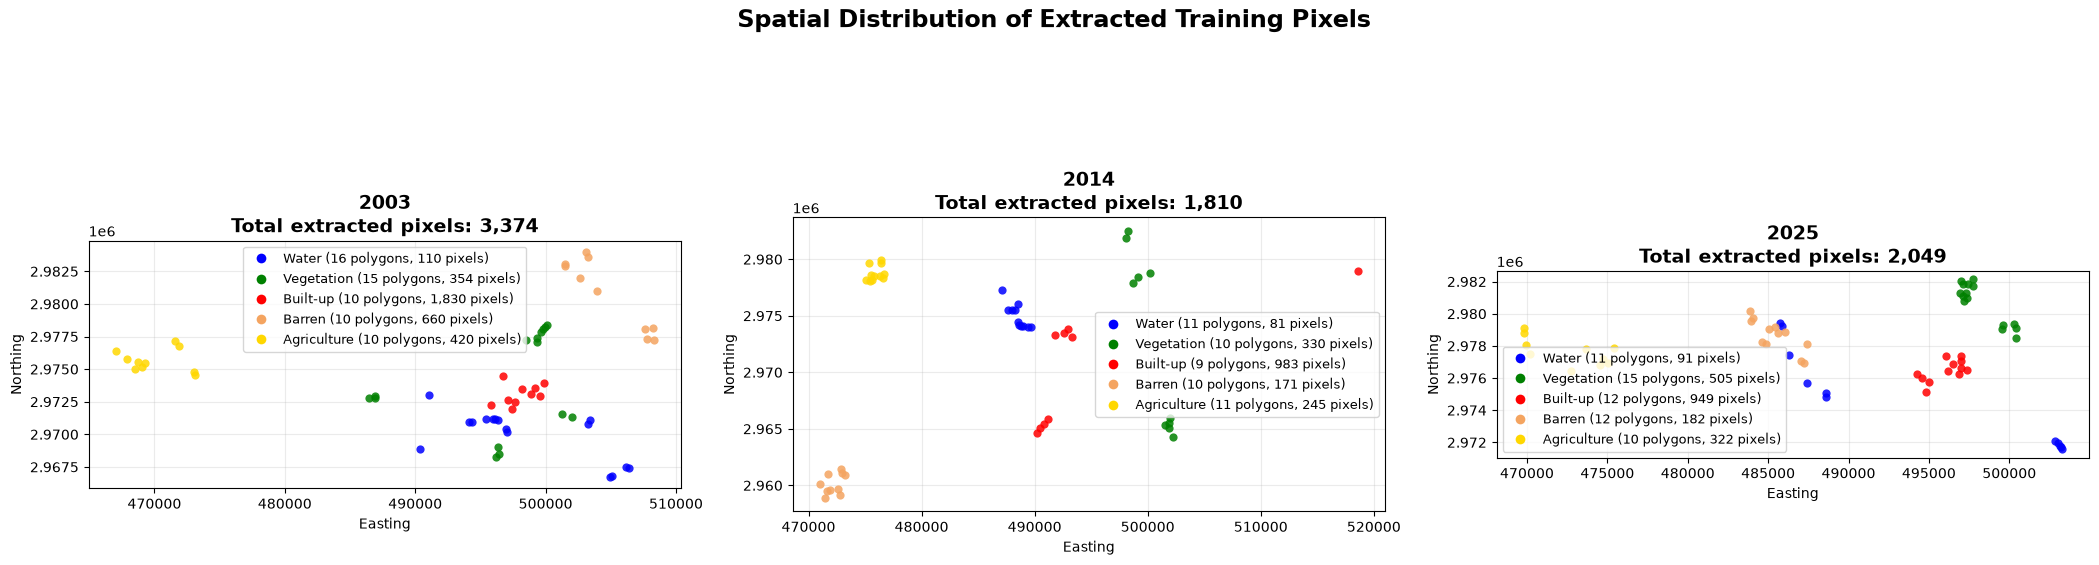

In [107]:
# ============================================================
# STEP 9 — VISUAL VERIFICATION OF EXTRACTED TRAINING PIXELS
# ============================================================
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables" 

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Correct class mapping
# ------------------------------------------------------------

CLASS_NAMES = {
    1: "Water",
    2: "Vegetation",
    3: "Built-up",
    4: "Barren",
    5: "Agriculture"
}

# Fixed colors for the five LULC classes
CLASS_COLORS = {
    1: "blue",
    2: "green",
    3: "red",
    4: "sandybrown",
    5: "gold"
}

YEARS = [2003, 2014, 2025]

# ------------------------------------------------------------
# Load the saved training-sample CSVs
# ------------------------------------------------------------

csv_paths = {
    year: TABLES_DIR /  "LULC_training_samples"  / f"LULC_training_samples_{year}.csv"
    for year in YEARS
}

training_data_plot = {
    year: pd.read_csv(csv_paths[year])
    for year in YEARS
}

# ------------------------------------------------------------
# Create one figure with three maps
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)

for ax, year in zip(axes, YEARS):

    df = training_data_plot[year]
    polygon_df = training_polygons[year]

    # --------------------------------------------------------
    # Plot training polygon centroids
    # --------------------------------------------------------

    for class_id in sorted(CLASS_NAMES.keys()):

        class_polygons = polygon_df[
            polygon_df["class_id"] == class_id
        ]

        if len(class_polygons) == 0:
            continue

        centroids = class_polygons.geometry.centroid

        ax.scatter(
            centroids.x,
            centroids.y,
            s=35,
            c=CLASS_COLORS[class_id],
            alpha=0.85,
            linewidths=0,
            zorder=2
        )

    # --------------------------------------------------------
    # Map formatting
    # --------------------------------------------------------

    ax.set_title(
        f"{year}\nTotal extracted pixels: {len(df):,}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

    ax.set_aspect("equal")

    ax.grid(
        True,
        alpha=0.25
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    handles = []

    for class_id in sorted(CLASS_NAMES.keys()):

        pixel_count = (
            df["class_id"]
            .eq(class_id)
            .sum()
        )

        polygon_count = (
            polygon_df["class_id"]
            .eq(class_id)
            .sum()
        )

        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=7,
                markerfacecolor=CLASS_COLORS[class_id],
                markeredgecolor="none",
                label=(
                    f"{CLASS_NAMES[class_id]} "
                    f"({polygon_count} polygons, "
                    f"{pixel_count:,} pixels)"
                )
            )
        )

    ax.legend(
        handles=handles,
        loc="best",
        fontsize=9,
        frameon=True
    )

# ------------------------------------------------------------
# Overall figure title
# ------------------------------------------------------------

fig.suptitle(
    "Spatial Distribution of Extracted Training Pixels",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 10. Training–Validation Dataset Preparation

The extracted pixel-level samples are divided into training and validation
datasets for supervised LULC classification.

To reduce spatial data leakage, the split is performed at the reference
polygon level rather than randomly at the individual-pixel level. Thus, all
pixels extracted from a given training polygon remain in the same subset.

The five LULC classes are retained consistently across all three observation
years:

1. Water
2. Vegetation
3. Built-up
4. Barren
5. Agriculture

The resulting training and validation datasets are used for Random Forest
model development and independent accuracy assessment.

### 10.1 Load Extracted Training Samples

The pixel-level training samples generated in Step 9 are loaded from the
outputs/tables directory.

Each sample contains the six Landsat spectral bands, three derived spectral
indices (NDVI, NDBI, and MNDWI), the LULC class ID, the source training
polygon ID, and the observation year.

These saved tables are used as the input for constructing the training and
validation datasets.

In [108]:
# ============================================================
# Step 10.1 — Load extracted training samples
# ============================================================

training_csvs = {
    2003: TABLES_DIR / "LULC_training_samples" / "LULC_training_samples_2003.csv",
    2014: TABLES_DIR / "LULC_training_samples" / "LULC_training_samples_2014.csv",
    2025: TABLES_DIR / "LULC_training_samples" / "LULC_training_samples_2025.csv"
}

training_data = {}

for year, path in training_csvs.items():

    training_data[year] = pd.read_csv(path)

    print(
        f"{year}: "
        f"{len(training_data[year]):,} samples loaded"
    )

2003: 3,374 samples loaded
2014: 1,810 samples loaded
2025: 2,049 samples loaded


### 10.2 Examine Training Polygon Distribution

The number of unique reference polygons contributing samples to each LULC
class is examined for every observation year.

Because pixels originating from the same polygon are spatially related,
polygon ID is treated as the independent sampling unit for the subsequent
training–validation split.

This prevents pixels from the same reference polygon from appearing in both
the training and validation datasets.

In [109]:
# ============================================================
# Step 10.2 — Count unique training polygons per class
# ============================================================

for year, df in training_data.items():

    print("\n" + "=" * 65)
    print(f"TRAINING POLYGONS PER CLASS — {year}")
    print("=" * 65)

    polygon_counts = (
        df.groupby("class_id")["polygon_id"]
        .nunique()
        .sort_index()
    )

    for class_id, count in polygon_counts.items():

        print(
            f"{class_id} - "
            f"{training_classes[class_id]:<15} : "
            f"{count} polygons"
        )


TRAINING POLYGONS PER CLASS — 2003
1 - Water           : 15 polygons
2 - Vegetation      : 15 polygons
3 - Built-up        : 10 polygons
4 - Barren          : 10 polygons
5 - Agriculture     : 10 polygons

TRAINING POLYGONS PER CLASS — 2014
1 - Water           : 11 polygons
2 - Vegetation      : 10 polygons
3 - Built-up        : 9 polygons
4 - Barren          : 10 polygons
5 - Agriculture     : 11 polygons

TRAINING POLYGONS PER CLASS — 2025
1 - Water           : 11 polygons
2 - Vegetation      : 15 polygons
3 - Built-up        : 12 polygons
4 - Barren          : 12 polygons
5 - Agriculture     : 10 polygons


### 10.3 Polygon-Level Train–Validation Split

The extracted samples are divided into training and validation subsets using
the reference training polygon as the sampling unit.

Approximately 80% of the polygons from each LULC class are assigned to the
training subset and the remaining polygons are assigned to the validation
subset.

All pixels belonging to the same polygon remain in the same subset. This
prevents spatially related pixels from the same reference polygon from
appearing simultaneously in the training and validation datasets.

The split is performed independently for each observation year while
maintaining the same five LULC classes:

1. Water
2. Vegetation
3. Built-up
4. Barren
5. Agriculture

A fixed random seed is used so that the split is reproducible.

In [110]:
# ============================================================
# Step 10.3 — Polygon-level stratified train/validation split
# ============================================================

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
VALIDATION_FRACTION = 0.20

train_data = {}
validation_data = {}

for year, df in training_data.items():

    train_parts = []
    validation_parts = []

    # --------------------------------------------------------
    # Split polygons separately for every class
    # --------------------------------------------------------

    for class_id in sorted(df["class_id"].unique()):

        class_df = df[df["class_id"] == class_id].copy()

        # Unique polygons belonging to this class
        polygon_ids = class_df["polygon_id"].unique()

        # ----------------------------------------------------
        # Select validation polygons
        # ----------------------------------------------------

        train_polygons, validation_polygons = train_test_split(
            polygon_ids,
            test_size=VALIDATION_FRACTION,
            random_state=RANDOM_STATE
        )

        # ----------------------------------------------------
        # Convert polygon selection back to pixels
        # ----------------------------------------------------

        class_train = class_df[
            class_df["polygon_id"].isin(train_polygons)
        ]

        class_validation = class_df[
            class_df["polygon_id"].isin(validation_polygons)
        ]

        train_parts.append(class_train)
        validation_parts.append(class_validation)

    # --------------------------------------------------------
    # Combine all classes
    # --------------------------------------------------------

    train_data[year] = pd.concat(
        train_parts,
        ignore_index=True
    )

    validation_data[year] = pd.concat(
        validation_parts,
        ignore_index=True
    )

    print("\n" + "=" * 65)
    print(f"TRAIN / VALIDATION SPLIT — {year}")
    print("=" * 65)

    print(
        f"Training pixels:   {len(train_data[year]):,}"
    )

    print(
        f"Validation pixels: {len(validation_data[year]):,}"
    )

    print(
        f"Training polygons:   "
        f"{train_data[year]['polygon_id'].nunique()}"
    )

    print(
        f"Validation polygons: "
        f"{validation_data[year]['polygon_id'].nunique()}"
    )


TRAIN / VALIDATION SPLIT — 2003
Training pixels:   2,579
Validation pixels: 795
Training polygons:   48
Validation polygons: 12

TRAIN / VALIDATION SPLIT — 2014
Training pixels:   1,504
Validation pixels: 306
Training polygons:   39
Validation polygons: 12

TRAIN / VALIDATION SPLIT — 2025
Training pixels:   1,567
Validation pixels: 482
Training polygons:   46
Validation polygons: 14


In [111]:
# ============================================================
# Verify polygon-level separation
# ============================================================

for year in training_data:

    train_polygons = set(
        train_data[year]["polygon_id"].unique()
    )

    validation_polygons = set(
        validation_data[year]["polygon_id"].unique()
    )

    overlap = train_polygons.intersection(
        validation_polygons
    )

    print("\n" + "=" * 65)
    print(f"POLYGON LEAKAGE CHECK — {year}")
    print("=" * 65)

    print(
        f"Training polygons:   {len(train_polygons)}"
    )

    print(
        f"Validation polygons: {len(validation_polygons)}"
    )

    print(
        f"Overlapping polygons: {len(overlap)}"
    )


POLYGON LEAKAGE CHECK — 2003
Training polygons:   48
Validation polygons: 12
Overlapping polygons: 0

POLYGON LEAKAGE CHECK — 2014
Training polygons:   39
Validation polygons: 12
Overlapping polygons: 0

POLYGON LEAKAGE CHECK — 2025
Training polygons:   46
Validation polygons: 14
Overlapping polygons: 0


### 10.4 Verify Class Distribution After Splitting

The class distribution of the training and validation datasets is examined
after the polygon-level split.

This ensures that every LULC class is represented in both subsets and that
the polygon-level split has not unintentionally excluded any class from the
validation dataset.

The number of pixels is reported because different training polygons contain
different numbers of valid pixels.

In [112]:
# ============================================================
# Step 10.4 — Verify class distribution after the split
# ============================================================

for year in training_data.keys():

    print("\n" + "=" * 70)
    print(f"CLASS DISTRIBUTION AFTER SPLIT — {year}")
    print("=" * 70)

    print("\nTRAINING DATA")

    train_counts = (
        train_data[year]["class_id"]
        .value_counts()
        .sort_index()
    )

    for class_id, count in train_counts.items():

        print(
            f"{class_id} - "
            f"{training_classes[class_id]:<15} : "
            f"{count:,} pixels"
        )

    print("\nVALIDATION DATA")

    validation_counts = (
        validation_data[year]["class_id"]
        .value_counts()
        .sort_index()
    )

    for class_id, count in validation_counts.items():

        print(
            f"{class_id} - "
            f"{training_classes[class_id]:<15} : "
            f"{count:,} pixels"
        )


CLASS DISTRIBUTION AFTER SPLIT — 2003

TRAINING DATA
1 - Water           : 92 pixels
2 - Vegetation      : 201 pixels
3 - Built-up        : 1,457 pixels
4 - Barren          : 519 pixels
5 - Agriculture     : 310 pixels

VALIDATION DATA
1 - Water           : 18 pixels
2 - Vegetation      : 153 pixels
3 - Built-up        : 373 pixels
4 - Barren          : 141 pixels
5 - Agriculture     : 110 pixels

CLASS DISTRIBUTION AFTER SPLIT — 2014

TRAINING DATA
1 - Water           : 65 pixels
2 - Vegetation      : 292 pixels
3 - Built-up        : 847 pixels
4 - Barren          : 124 pixels
5 - Agriculture     : 176 pixels

VALIDATION DATA
1 - Water           : 16 pixels
2 - Vegetation      : 38 pixels
3 - Built-up        : 136 pixels
4 - Barren          : 47 pixels
5 - Agriculture     : 69 pixels

CLASS DISTRIBUTION AFTER SPLIT — 2025

TRAINING DATA
1 - Water           : 69 pixels
2 - Vegetation      : 396 pixels
3 - Built-up        : 700 pixels
4 - Barren          : 134 pixels
5 - Agriculture   

### 10.5 Define Predictor and Target Variables

The nine spectral and spectral-index variables are defined as the predictor
variables for supervised LULC classification.

The LULC class ID is used as the target variable.

Polygon ID and observation year are retained as metadata but are excluded
from the predictor matrix to prevent them from influencing classification.

In [113]:
# ============================================================
# Step 10.5 — Define predictors and target
# ============================================================

feature_columns = [
    "blue",
    "green",
    "red",
    "nir",
    "swir1",
    "swir2",
    "NDVI",
    "NDBI",
    "MNDWI"
]

target_column = "class_id"

metadata_columns = [
    "polygon_id",
    "year"
]

print("Predictor variables:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i}. {feature}")

print("\nTarget variable:")
print(target_column)

print("\nExcluded metadata:")
for column in metadata_columns:
    print(column)

Predictor variables:
1. blue
2. green
3. red
4. nir
5. swir1
6. swir2
7. NDVI
8. NDBI
9. MNDWI

Target variable:
class_id

Excluded metadata:
polygon_id
year


In [114]:
# ============================================================
# Verify required columns
# ============================================================

for year in training_data.keys():

    required_columns = (
        feature_columns
        + [target_column]
        + metadata_columns
    )

    missing = [
        column
        for column in required_columns
        if column not in training_data[year].columns
    ]

    print(
        f"{year}: "
        f"{'All required columns present' if not missing else 'Missing: ' + str(missing)}"
    )

2003: All required columns present
2014: All required columns present
2025: All required columns present


### 10.6 Create Machine-Learning Input Matrices

The polygon-level training and validation datasets are converted into
predictor matrices (X) and target vectors (y) for supervised machine
learning.

The nine spectral and spectral-index variables are used as predictors:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2
- NDVI
- NDBI
- MNDWI

The LULC class ID is used as the target variable.

Polygon ID and year are excluded from the predictor matrix because they are
metadata rather than explanatory variables.

In [115]:
# ============================================================
# Step 10.6 — Create ML input matrices
# ============================================================

X_train = {}
y_train = {}

X_validation = {}
y_validation = {}

for year in training_data.keys():

    # Training predictors
    X_train[year] = train_data[year][feature_columns].copy()

    # Training target
    y_train[year] = train_data[year][target_column].copy()

    # Validation predictors
    X_validation[year] = (
        validation_data[year][feature_columns].copy()
    )

    # Validation target
    y_validation[year] = (
        validation_data[year][target_column].copy()
    )

    print("\n" + "=" * 65)
    print(f"ML MATRICES — {year}")
    print("=" * 65)

    print(
        f"X_train:        {X_train[year].shape}"
    )

    print(
        f"y_train:        {y_train[year].shape}"
    )

    print(
        f"X_validation:   {X_validation[year].shape}"
    )

    print(
        f"y_validation:   {y_validation[year].shape}"
    )


ML MATRICES — 2003
X_train:        (2579, 9)
y_train:        (2579,)
X_validation:   (795, 9)
y_validation:   (795,)

ML MATRICES — 2014
X_train:        (1504, 9)
y_train:        (1504,)
X_validation:   (306, 9)
y_validation:   (306,)

ML MATRICES — 2025
X_train:        (1567, 9)
y_train:        (1567,)
X_validation:   (482, 9)
y_validation:   (482,)


### 10.7 Predictor Quality Check

The predictor matrices are checked for missing, infinite, or otherwise
invalid numerical values before they are passed to the Random Forest
classifier.

This ensures that invalid raster values do not enter the machine-learning
workflow.

In [116]:
# ============================================================
# Step 10.7 — Check predictors for invalid values
# ============================================================

for year in training_data.keys():

    Xtr = X_train[year]
    Xval = X_validation[year]

    train_nan = Xtr.isna().sum().sum()
    val_nan = Xval.isna().sum().sum()

    train_inf = np.isinf(Xtr.to_numpy()).sum()
    val_inf = np.isinf(Xval.to_numpy()).sum()

    print("\n" + "=" * 65)
    print(f"PREDICTOR QUALITY CHECK — {year}")
    print("=" * 65)

    print(f"Training NaN values:      {train_nan:,}")
    print(f"Validation NaN values:    {val_nan:,}")
    print(f"Training infinite:        {train_inf:,}")
    print(f"Validation infinite:      {val_inf:,}")


PREDICTOR QUALITY CHECK — 2003
Training NaN values:      0
Validation NaN values:    0
Training infinite:        0
Validation infinite:      0

PREDICTOR QUALITY CHECK — 2014
Training NaN values:      0
Validation NaN values:    0
Training infinite:        0
Validation infinite:      0

PREDICTOR QUALITY CHECK — 2025
Training NaN values:      0
Validation NaN values:    0
Training infinite:        0
Validation infinite:      0


## 11. Random Forest LULC Classification

A Random Forest classifier is used to classify the study area into five
land-use/land-cover classes using six Landsat spectral bands and three
spectral indices.

The nine predictor variables are:

- Blue
- Green
- Red
- NIR
- SWIR1
- SWIR2
- NDVI
- NDBI
- MNDWI

Separate Random Forest models are trained for 2003, 2014, and 2025 using
the polygon-level training samples prepared in Step 10.

The validation samples remain independent of model training and are used
later for accuracy assessment.

### 11.1 Import Random Forest 

In [117]:
# ============================================================
# Step 11.1 — Import Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


### 11.2 Random Forest Model Configuration

A baseline Random Forest configuration is defined using a fixed number of
decision trees and a fixed random state.

The same model configuration is initially applied independently to each
observation year so that the resulting classifications are comparable.

Hyperparameter optimization, if required, can be performed after evaluating
the baseline model.

In [118]:
# ============================================================
# Step 11.2 — Random Forest configuration
# ============================================================

RF_N_ESTIMATORS = 300
RF_RANDOM_STATE = 42
RF_N_JOBS = -1

print("Random Forest configuration:")
print(f"Number of trees : {RF_N_ESTIMATORS}")
print(f"Random state    : {RF_RANDOM_STATE}")
print(f"Parallel jobs   : {RF_N_JOBS}")

Random Forest configuration:
Number of trees : 300
Random state    : 42
Parallel jobs   : -1


### 11.3 Train Random Forest Models

A separate Random Forest classifier is trained for each observation year.

The models learn the relationship between the nine predictor variables and
the five LULC classes using only the training polygons.

The validation datasets are not used during model fitting.

In [119]:
# ============================================================
# Step 11.3 — Train Random Forest models
# ============================================================

rf_models = {}

for year in training_data.keys():

    print("\n" + "=" * 65)
    print(f"TRAINING RANDOM FOREST — {year}")
    print("=" * 65)

    model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        n_jobs=RF_N_JOBS
    )

    model.fit(
        X_train[year],
        y_train[year]
    )

    rf_models[year] = model

    print("Model trained successfully.")
    print(
        f"Training samples: {len(X_train[year]):,}"
    )


TRAINING RANDOM FOREST — 2003
Model trained successfully.
Training samples: 2,579

TRAINING RANDOM FOREST — 2014
Model trained successfully.
Training samples: 1,504

TRAINING RANDOM FOREST — 2025
Model trained successfully.
Training samples: 1,567


### 11.4 Validation Predictions

The trained Random Forest models are applied to the independent validation
samples for each observation year.

The validation samples were excluded from model fitting and consist of
pixels belonging to polygons that were not used for training.

Predicted LULC classes are compared with the known reference class IDs to
evaluate model performance.

In [120]:
# ============================================================
# Step 11.4 — Predict validation samples
# ============================================================

validation_predictions = {}

for year in training_data.keys():

    print("\n" + "=" * 65)
    print(f"VALIDATION PREDICTION — {year}")
    print("=" * 65)

    predictions = rf_models[year].predict(
        X_validation[year]
    )

    validation_predictions[year] = predictions

    print(
        f"Validation samples: {len(predictions):,}"
    )

    print(
        f"Predictions generated: {len(predictions):,}"
    )


VALIDATION PREDICTION — 2003
Validation samples: 795
Predictions generated: 795

VALIDATION PREDICTION — 2014
Validation samples: 306
Predictions generated: 306

VALIDATION PREDICTION — 2025
Validation samples: 482
Predictions generated: 482


### 11.5 Accuracy Assessment

Model performance is evaluated using the independent validation samples.

The confusion matrix shows the agreement and disagreement between the
reference LULC classes and the Random Forest predictions.

Overall Accuracy (OA), macro-averaged F1-score, and Cohen's Kappa are
calculated to provide complementary measures of classification performance.
Per-class precision, recall, and F1-score are also reported.

These metrics are calculated independently for 2003, 2014, and 2025.

In [121]:
# ============================================================
# Step 11.5 — Accuracy assessment
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    f1_score
)

class_ids = [1, 2, 3, 4, 5]

accuracy_results = {}

for year in training_data.keys():

    y_true = y_validation[year]
    y_pred = validation_predictions[year]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_ids
    )

    overall_accuracy = accuracy_score(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=class_ids,
        average="macro"
    )

    accuracy_results[year] = {
        "confusion_matrix": cm,
        "overall_accuracy": overall_accuracy,
        "kappa": kappa,
        "macro_f1": macro_f1
    }

    print("\n" + "=" * 70)
    print(f"ACCURACY ASSESSMENT — {year}")
    print("=" * 70)

    print(
        f"Overall Accuracy : {overall_accuracy:.4f} "
        f"({overall_accuracy * 100:.2f}%)"
    )

    print(
        f"Cohen's Kappa    : {kappa:.4f}"
    )

    print(
        f"Macro F1-score   : {macro_f1:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            labels=class_ids,
            target_names=[
                training_classes[i]
                for i in class_ids
            ],
            digits=4
        )
    )


ACCURACY ASSESSMENT — 2003
Overall Accuracy : 0.9396 (93.96%)
Cohen's Kappa    : 0.9124
Macro F1-score   : 0.9173

Confusion Matrix:
[[ 14   0   4   0   0]
 [  0 133   9   0  11]
 [  0  10 363   0   0]
 [  0   0   0 141   0]
 [  0  13   0   1  96]]

Classification Report:
              precision    recall  f1-score   support

       Water     1.0000    0.7778    0.8750        18
  Vegetation     0.8526    0.8693    0.8608       153
    Built-up     0.9654    0.9732    0.9693       373
      Barren     0.9930    1.0000    0.9965       141
 Agriculture     0.8972    0.8727    0.8848       110

    accuracy                         0.9396       795
   macro avg     0.9416    0.8986    0.9173       795
weighted avg     0.9399    0.9396    0.9394       795


ACCURACY ASSESSMENT — 2014
Overall Accuracy : 1.0000 (100.00%)
Cohen's Kappa    : 1.0000
Macro F1-score   : 1.0000

Confusion Matrix:
[[ 16   0   0   0   0]
 [  0  38   0   0   0]
 [  0   0 136   0   0]
 [  0   0   0  47   0]
 [  0   0 

### 11.6 Random Forest Feature Importance

Feature importance is extracted from each trained Random Forest model to
identify the relative contribution of the nine predictor variables to LULC
classification.

The importance values are examined independently for 2003, 2014, and 2025.

This provides insight into whether the classification is driven primarily
by the original Landsat spectral bands or by the derived indices NDVI, NDBI,
and MNDWI.

In [122]:
# ============================================================
# Step 11.6 — Feature importance
# ============================================================

feature_importance = {}

for year, model in rf_models.items():

    importance = pd.Series(
        model.feature_importances_,
        index=feature_columns
    ).sort_values(ascending=False)

    feature_importance[year] = importance

    print("\n" + "=" * 70)
    print(f"FEATURE IMPORTANCE — {year}")
    print("=" * 70)

    for feature, value in importance.items():
        print(f"{feature:<10} : {value:.4f}")


FEATURE IMPORTANCE — 2003
blue       : 0.1791
red        : 0.1575
nir        : 0.1495
green      : 0.1260
NDVI       : 0.0922
NDBI       : 0.0860
swir2      : 0.0780
swir1      : 0.0719
MNDWI      : 0.0598

FEATURE IMPORTANCE — 2014
red        : 0.2102
blue       : 0.1883
green      : 0.1406
NDVI       : 0.1294
NDBI       : 0.1282
swir2      : 0.0778
nir        : 0.0572
MNDWI      : 0.0409
swir1      : 0.0275

FEATURE IMPORTANCE — 2025
red        : 0.1669
nir        : 0.1588
NDBI       : 0.1380
swir1      : 0.1210
blue       : 0.1187
green      : 0.1061
swir2      : 0.0852
NDVI       : 0.0841
MNDWI      : 0.0212


In [123]:
# ============================================================
# Verify feature importance sums
# ============================================================

for year, importance in feature_importance.items():

    print(
        f"{year}: "
        f"sum = {importance.sum():.6f}"
    )

2003: sum = 1.000000
2014: sum = 1.000000
2025: sum = 1.000000


### 11.7 Save Random Forest Validation Results

The validation metrics, confusion matrices, and per-class classification
reports are saved for each observation year.

These outputs provide a permanent record of Random Forest performance and
will be used later for interpretation and reporting of the LULC
classification results.

In [124]:
# ============================================================
# Step 11.7 — Save validation results
# ============================================================

# Make sure output directories exist
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Overall validation metrics
# ------------------------------------------------------------

metrics_rows = []

for year, results in accuracy_results.items():

    metrics_rows.append({
        "year": year,
        "overall_accuracy": results["overall_accuracy"],
        "kappa": results["kappa"],
        "macro_f1": results["macro_f1"]
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_path = TABLES_DIR / "RF_Validation"/ "RF_validation_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(f"Saved: {metrics_path}")


# ------------------------------------------------------------
# 2. Confusion matrices
# ------------------------------------------------------------

for year, results in accuracy_results.items():

    cm_df = pd.DataFrame(
        results["confusion_matrix"],
        index=[
            f"Reference_{training_classes[i]}"
            for i in class_ids
        ],
        columns=[
            f"Predicted_{training_classes[i]}"
            for i in class_ids
        ]
    )

    cm_path = (
        TABLES_DIR / "RF_Validation" /
        f"RF_confusion_matrix_{year}.csv"
    )

    cm_df.to_csv(cm_path)

    print(f"Saved: {cm_path}")


# ------------------------------------------------------------
# 3. Classification reports
# ------------------------------------------------------------

for year in training_data.keys():

    y_true = y_validation[year]
    y_pred = validation_predictions[year]

    report = classification_report(
        y_true,
        y_pred,
        labels=class_ids,
        target_names=[
            training_classes[i]
            for i in class_ids
        ],
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    report_path = (
        TABLES_DIR / "RF_Validation" /
        f"RF_classification_report_{year}.csv"
    )

    report_df.to_csv(report_path)

    print(f"Saved: {report_path}")

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_validation_metrics.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_confusion_matrix_2003.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_confusion_matrix_2014.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_confusion_matrix_2025.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_classification_report_2003.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_classification_report_2014.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Validation\RF_classification_report_2025.csv


In [125]:
# ============================================================
# Verify saved validation files
# ============================================================

print("\nValidation output files:")

for path in sorted(TABLES_DIR.glob("RF_*")):
    print(path.name)
    


Validation output files:
RF_Feature_Importance
RF_Validation


### 11.8 Save Random Forest Feature Importance

The feature-importance values derived from each Random Forest model are
saved as CSV tables for reproducibility and later interpretation.

Each table contains the nine predictor variables and their corresponding
relative importance values for the respective observation year.

In [126]:
# ============================================================
# Step 11.8 — Save feature importance tables
# ============================================================

for year, importance in feature_importance.items():

    importance_df = (
        importance
        .rename("importance")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    importance_path = (
        TABLES_DIR / "RF_Feature_Importance"/
        f"RF_feature_importance_{year}.csv"
    )

    importance_df.to_csv(
        importance_path,
        index=False
    )

    print(f"Saved: {importance_path}")

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Feature_Importance\RF_feature_importance_2003.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Feature_Importance\RF_feature_importance_2014.csv
Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\RF_Feature_Importance\RF_feature_importance_2025.csv


### 11.9 Visualize Random Forest Feature Importance

Feature importance is visualized separately for each observation year.

The predictors are ranked from highest to lowest importance to show which
spectral bands and derived indices contributed most strongly to the
Random Forest classification.

The figures are saved as PNG files for later use in the research paper.

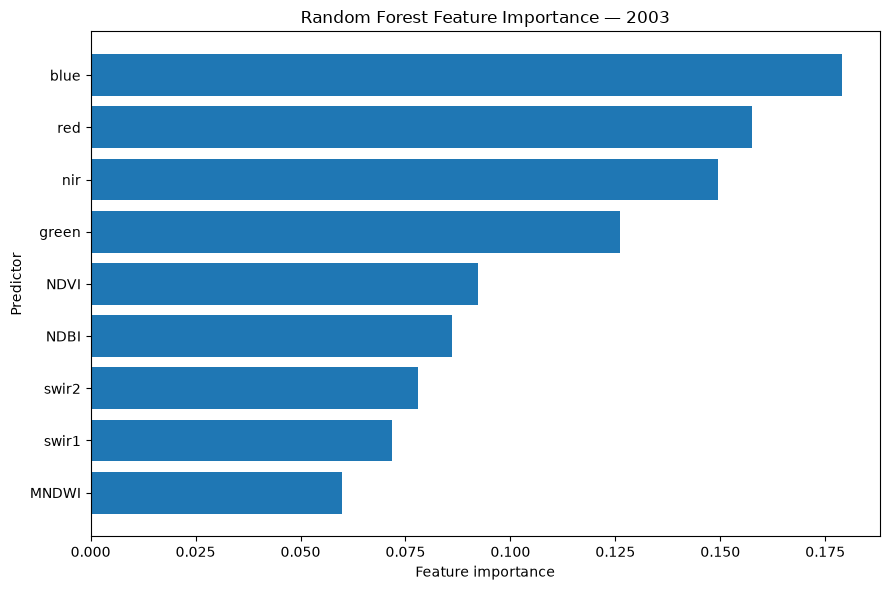

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_04\RF_feature_importance_2003.png


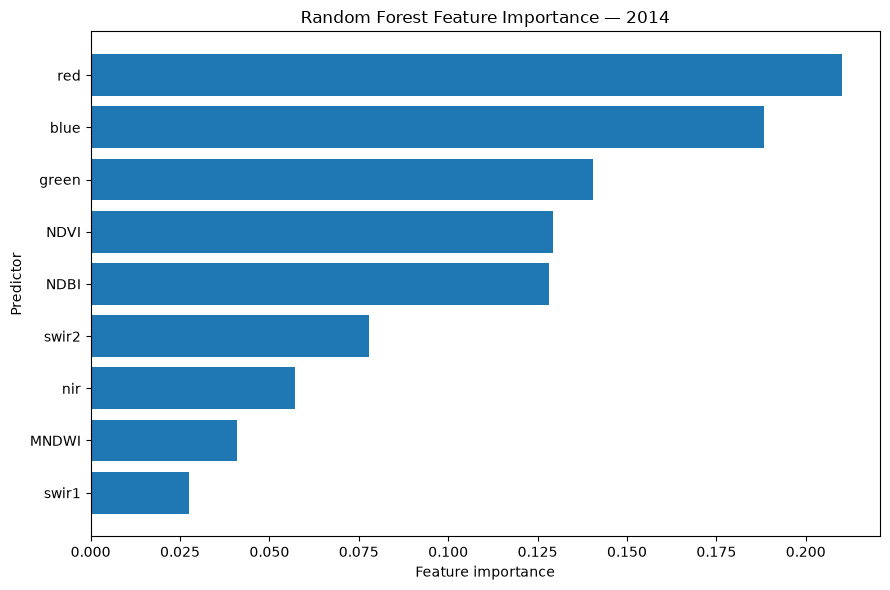

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_04\RF_feature_importance_2014.png


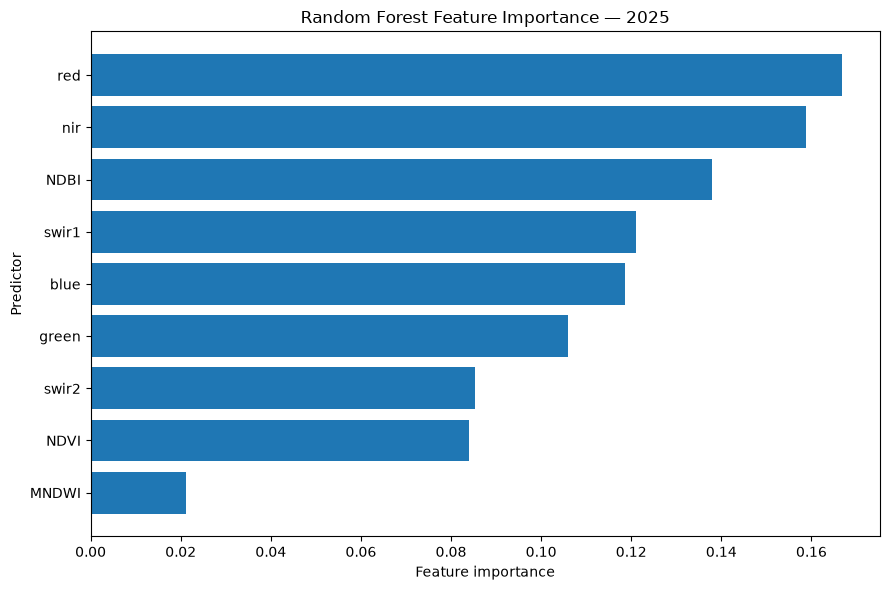

Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_04\RF_feature_importance_2025.png


In [127]:
# ============================================================
# Step 11.9 — Plot and save feature importance
# ============================================================

import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "notebook_04" 
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for year, importance in feature_importance.items():

    # Sort from highest to lowest
    importance_sorted = importance.sort_values(
        ascending=True
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        importance_sorted.index,
        importance_sorted.values
    )

    plt.xlabel("Feature importance")
    plt.ylabel("Predictor")
    plt.title(
        f"Random Forest Feature Importance — {year}"
    )

    plt.tight_layout()

    output_path = (
        FIGURES_DIR /
        f"RF_feature_importance_{year}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(f"Saved: {output_path}")

### 12.1 Verify Full-Study-Area Predictor Rasters

The nine predictor variables used during Random Forest training are assembled
from the saved spectral-band VRTs and derived spectral-index rasters.

The six spectral predictors are obtained from two three-band VRT files:

- Blue
- Red
- Green
- NIR
- SWIR1
- SWIR2

The remaining predictors are the saved NDVI, NDBI, and MNDWI rasters.

Before full-study-area classification, all nine predictors are checked for
consistent raster dimensions, CRS, spatial transform, and resolution.

In [134]:
# ============================================================
# Step 12.1 — Verify the 9-feature raster stack
# ============================================================

import rasterio

feature_raster_paths = {}

for year in [2003, 2014, 2025]:

    base = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_04"
    )

    training_dir = base / "training_samples"
    year_dir = base / str(year)

    feature_raster_paths[year] = {
        "blue": training_dir / f"BLUE_RED_GREEN_{year}.vrt",
        "red": training_dir / f"BLUE_RED_GREEN_{year}.vrt",
        "green": training_dir / f"BLUE_RED_GREEN_{year}.vrt",

        "nir": training_dir / f"NIR_SWIR1_SWIR2_{year}.vrt",
        "swir1": training_dir / f"NIR_SWIR1_SWIR2_{year}.vrt",
        "swir2": training_dir / f"NIR_SWIR1_SWIR2_{year}.vrt",

        "NDVI": year_dir / f"NDVI_{year}.tif",
        "NDBI": year_dir / f"NDBI_{year}.tif",
        "MNDWI": year_dir / f"MNDWI_{year}.tif"
    }

vrt_band_numbers = {
    "blue": 1,
    "red": 2,
    "green": 3,
    "nir": 1,
    "swir1": 2,
    "swir2": 3
}

for year in [2003, 2014, 2025]:

    print("\n" + "=" * 70)
    print(f"9-FEATURE SPATIAL CHECK — {year}")
    print("=" * 70)

    reference = None
    alignment_ok = True

    for feature in feature_columns:

        path = feature_raster_paths[year][feature]

        with rasterio.open(path) as src:

            info = {
                "shape": src.shape,
                "crs": src.crs,
                "transform": src.transform,
                "resolution": src.res,
                "bounds": src.bounds
            }

            print(
                f"{feature:<8} | "
                f"shape={src.shape} | "
                f"resolution={src.res}"
            )

            if reference is None:
                reference = info

            else:
                if info["shape"] != reference["shape"]:
                    alignment_ok = False

                if info["crs"] != reference["crs"]:
                    alignment_ok = False

                if info["transform"] != reference["transform"]:
                    alignment_ok = False

                if info["resolution"] != reference["resolution"]:
                    alignment_ok = False

                if info["bounds"] != reference["bounds"]:
                    alignment_ok = False

    print()

    if alignment_ok:
        print("✓ All 9 predictors are spatially aligned.")
    else:
        print("✗ Spatial alignment problem detected.")


9-FEATURE SPATIAL CHECK — 2003
blue     | shape=(7111, 7861) | resolution=(30.0, 30.0)
green    | shape=(7111, 7861) | resolution=(30.0, 30.0)
red      | shape=(7111, 7861) | resolution=(30.0, 30.0)
nir      | shape=(7111, 7861) | resolution=(30.0, 30.0)
swir1    | shape=(7111, 7861) | resolution=(30.0, 30.0)
swir2    | shape=(7111, 7861) | resolution=(30.0, 30.0)
NDVI     | shape=(7111, 7861) | resolution=(30.0, 30.0)
NDBI     | shape=(7111, 7861) | resolution=(30.0, 30.0)
MNDWI    | shape=(7111, 7861) | resolution=(30.0, 30.0)

✓ All 9 predictors are spatially aligned.

9-FEATURE SPATIAL CHECK — 2014
blue     | shape=(7801, 7651) | resolution=(30.0, 30.0)
green    | shape=(7801, 7651) | resolution=(30.0, 30.0)
red      | shape=(7801, 7651) | resolution=(30.0, 30.0)
nir      | shape=(7801, 7651) | resolution=(30.0, 30.0)
swir1    | shape=(7801, 7651) | resolution=(30.0, 30.0)
swir2    | shape=(7801, 7651) | resolution=(30.0, 30.0)
NDVI     | shape=(7801, 7651) | resolution=(30.0, 30.

### 12.2 Full-Study-Area Random Forest Prediction

The trained Random Forest model for each observation year is applied to the
complete study-area raster stack.

The nine predictors are:

1. Blue
2. Green
3. Red
4. NIR
5. SWIR1
6. SWIR2
7. NDVI
8. NDBI
9. MNDWI

Prediction is performed block-by-block to avoid loading the complete
multi-million-pixel study area into memory at once.

Pixels for which one or more predictor values are invalid are assigned the
output nodata value 0. Valid pixels are classified into the five LULC
classes:

1. Water
2. Vegetation
3. Built-up
4. Barren
5. Agriculture

In [137]:
# ============================================================
# Step 12.2 — Full-study-area Random Forest prediction
#             ONLY inside the study area
# ============================================================

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

LULC_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "lulc_maps"
)

LULC_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# VRT band mapping
#
# BLUE_RED_GREEN:
#   Band 1 = Blue
#   Band 2 = Red
#   Band 3 = Green
#
# NIR_SWIR1_SWIR2:
#   Band 1 = NIR
#   Band 2 = SWIR1
#   Band 3 = SWIR2
#
# Index rasters:
#   Band 1 = index
# ------------------------------------------------------------

vrt_band_numbers = {
    "blue": 1,
    "red": 2,
    "green": 3,
    "nir": 1,
    "swir1": 2,
    "swir2": 3,
    "NDVI": 1,
    "NDBI": 1,
    "MNDWI": 1
}

# ------------------------------------------------------------
# Check that the study-area object exists
# ------------------------------------------------------------

if "study_area_gdf" not in globals():

    if "study_area_vector" in globals():

        study_area_gdf = study_area_vector.copy()

    elif "study_area_raster_crs" in globals():

        study_area_gdf = study_area_raster_crs.copy()

    else:

        raise NameError(
            "No study-area GeoDataFrame was found. "
            "Expected study_area_vector or study_area_raster_crs."
        )

print("Study-area GeoDataFrame found.")

# ------------------------------------------------------------
# Make sure study area uses the same CRS as Landsat
# ------------------------------------------------------------

if study_area_gdf.crs is None:

    raise ValueError(
        "study_area_gdf has no CRS."
    )

if str(study_area_gdf.crs) != "EPSG:32644":

    study_area_gdf = study_area_gdf.to_crs(
        "EPSG:32644"
    )

print(
    f"Study-area CRS: {study_area_gdf.crs}"
)

# ------------------------------------------------------------
# Process each year
# ------------------------------------------------------------

lulc_map_paths = {}

for year in [2003, 2014, 2025]:

    print("\n" + "=" * 70)
    print(f"FULL-STUDY-AREA CLASSIFICATION — {year}")
    print("=" * 70)

    model = rf_models[year]

    paths = feature_raster_paths[year]

    # --------------------------------------------------------
    # Open predictor rasters
    # --------------------------------------------------------

    sources = {
        feature: rasterio.open(paths[feature])
        for feature in feature_columns
    }

    try:

        reference_src = sources["NDVI"]

        height = reference_src.height
        width = reference_src.width

        # ----------------------------------------------------
        # Create study-area mask
        #
        # False = inside study area
        # True  = outside study area
        # ----------------------------------------------------

        study_mask = geometry_mask(
            study_area_gdf.geometry,
            out_shape=(height, width),
            transform=reference_src.transform,
            invert=False
        )

        study_area_pixels = np.count_nonzero(
            ~study_mask
        )

        print(
            f"Study-area pixels: {study_area_pixels:,}"
        )

        # ----------------------------------------------------
        # Output profile
        # ----------------------------------------------------

        profile = reference_src.profile.copy()

        profile.update(
            dtype="uint8",
            count=1,
            nodata=0,
            compress="lzw"
        )

        output_path = (
            LULC_OUTPUT_DIR
            / f"LULC_RF_{year}.tif"
        )

        # ----------------------------------------------------
        # Create output raster
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            classified_pixels = 0
            invalid_pixels = 0

            # ------------------------------------------------
            # Process in raster blocks
            # ------------------------------------------------

            for _, window in reference_src.block_windows(1):

                row_start = int(window.row_off)
                row_end = row_start + int(window.height)

                col_start = int(window.col_off)
                col_end = col_start + int(window.width)

                # --------------------------------------------
                # Study-area portion of this block
                # --------------------------------------------

                block_study_mask = study_mask[
                    row_start:row_end,
                    col_start:col_end
                ]

                # --------------------------------------------
                # Read nine predictors
                # --------------------------------------------

                arrays = []

                for feature in feature_columns:

                    src = sources[feature]

                    data = src.read(
                        vrt_band_numbers[feature],
                        window=window,
                        masked=True
                    )

                    data = data.astype(
                        np.float32
                    ).filled(np.nan)

                    arrays.append(data)

                # --------------------------------------------
                # Stack:
                #
                # rows × cols × 9
                # --------------------------------------------

                stack = np.stack(
                    arrays,
                    axis=-1
                )

                block_rows = stack.shape[0]
                block_cols = stack.shape[1]

                X_block = stack.reshape(
                    -1,
                    len(feature_columns)
                )

                # --------------------------------------------
                # Flatten study-area mask
                # --------------------------------------------

                study_flat = (
                    ~block_study_mask
                ).reshape(-1)

                # --------------------------------------------
                # Find pixels with valid values across
                # all nine predictors
                # --------------------------------------------

                finite_mask = np.all(
                    np.isfinite(X_block),
                    axis=1
                )

                valid_mask = (
                    study_flat
                    & finite_mask
                )

                # --------------------------------------------
                # Output block initially NoData
                # --------------------------------------------

                prediction_block = np.zeros(
                    X_block.shape[0],
                    dtype=np.uint8
                )

                # --------------------------------------------
                # Predict ONLY valid study-area pixels
                # --------------------------------------------

                if np.any(valid_mask):

                    X_valid = pd.DataFrame(
                        X_block[valid_mask],
                        columns=feature_columns
                    )

                    predictions = model.predict(
                        X_valid
                    )

                    prediction_block[valid_mask] = (
                        predictions.astype(np.uint8)
                    )

                    classified_pixels += (
                        np.count_nonzero(valid_mask)
                    )

                # --------------------------------------------
                # Count invalid pixels inside study area
                # --------------------------------------------

                invalid_inside = (
                    study_flat
                    & ~finite_mask
                )

                invalid_pixels += (
                    np.count_nonzero(invalid_inside)
                )

                # --------------------------------------------
                # Reshape and write
                # --------------------------------------------

                prediction_block = (
                    prediction_block.reshape(
                        block_rows,
                        block_cols
                    )
                )

                dst.write(
                    prediction_block,
                    1,
                    window=window
                )

        lulc_map_paths[year] = output_path

        print(
            f"Classified pixels : "
            f"{classified_pixels:,}"
        )

        print(
            f"Invalid pixels    : "
            f"{invalid_pixels:,}"
        )

        print(
            f"Output            : {output_path}"
        )

        print("✓ Classification completed.")

    finally:

        for src in sources.values():
            src.close()

print("\n" + "=" * 70)
print("ALL YEARS COMPLETED")
print("=" * 70)

for year, path in lulc_map_paths.items():
    print(f"{year}: {path}")

Study-area GeoDataFrame found.
Study-area CRS: EPSG:32644

FULL-STUDY-AREA CLASSIFICATION — 2003
Study-area pixels: 3,314,354
Classified pixels : 3,306,528
Invalid pixels    : 7,826
Output            : d:\Projects\GeoAI-Flood-Susceptibility\outputs\lulc_maps\LULC_RF_2003.tif
✓ Classification completed.

FULL-STUDY-AREA CLASSIFICATION — 2014
Study-area pixels: 3,314,354
Classified pixels : 3,205,074
Invalid pixels    : 109,280
Output            : d:\Projects\GeoAI-Flood-Susceptibility\outputs\lulc_maps\LULC_RF_2014.tif
✓ Classification completed.

FULL-STUDY-AREA CLASSIFICATION — 2025
Study-area pixels: 3,314,354
Classified pixels : 2,909,196
Invalid pixels    : 405,158
Output            : d:\Projects\GeoAI-Flood-Susceptibility\outputs\lulc_maps\LULC_RF_2025.tif
✓ Classification completed.

ALL YEARS COMPLETED
2003: d:\Projects\GeoAI-Flood-Susceptibility\outputs\lulc_maps\LULC_RF_2003.tif
2014: d:\Projects\GeoAI-Flood-Susceptibility\outputs\lulc_maps\LULC_RF_2014.tif
2025: d:\Projects\G

### 12.3 Visualize Full-Study-Area LULC Classification

The final Random Forest LULC classification rasters are visualized for the
three observation years.

The same class-color scheme and class IDs are used across all years to allow
direct visual comparison.

The number of classified pixels belonging to each LULC class is reported
within each map for verification before subsequent area and change analysis.

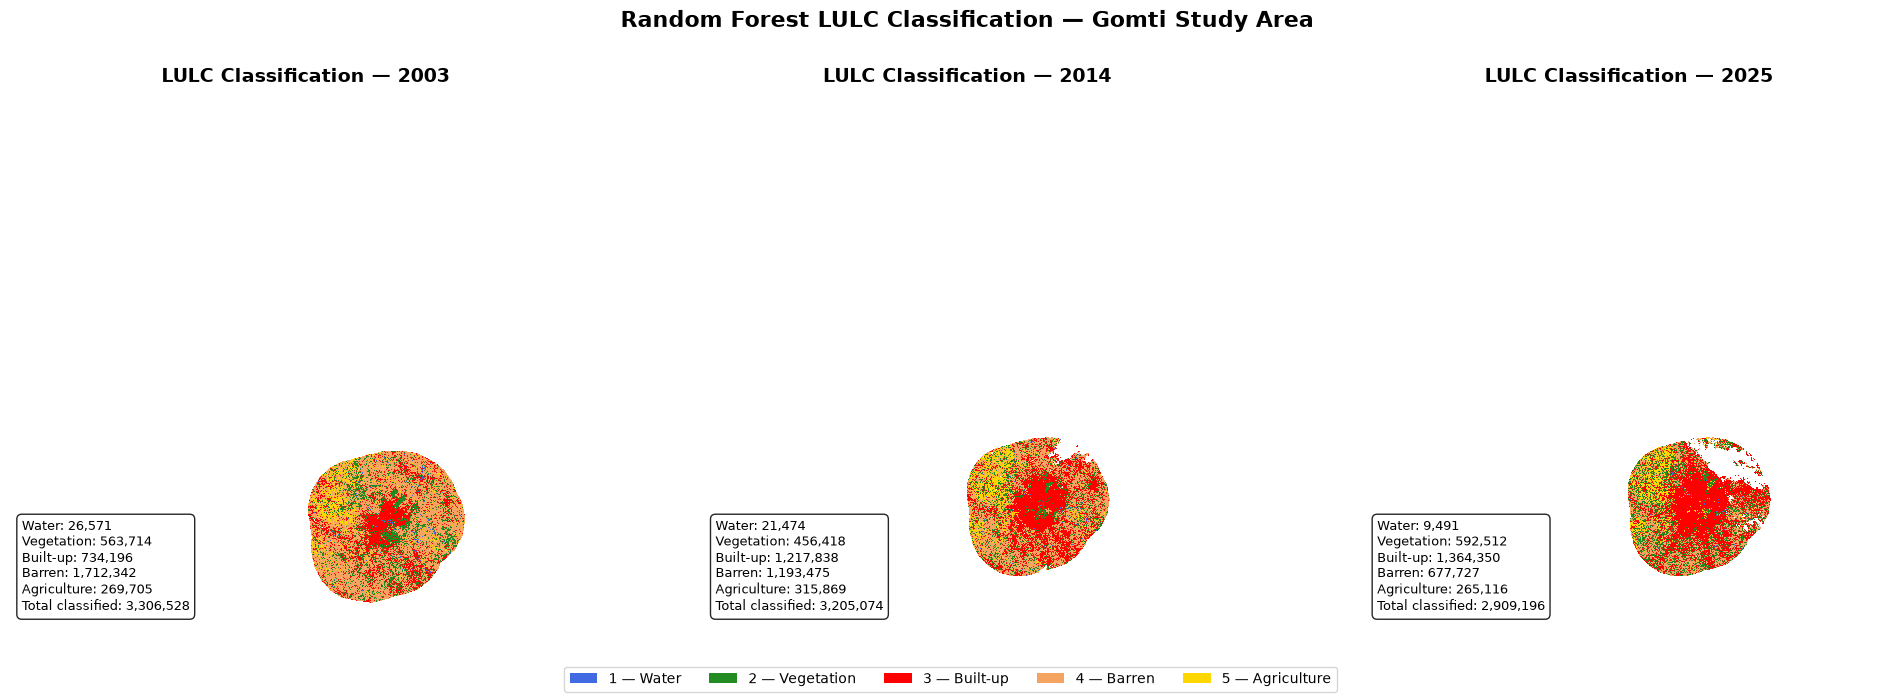

In [138]:
# ============================================================
# Step 12.3 — Plot final LULC maps
# ============================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ------------------------------------------------------------
# LULC class definitions
# ------------------------------------------------------------

class_ids = [1, 2, 3, 4, 5]

class_names = {
    1: "Water",
    2: "Vegetation",
    3: "Built-up",
    4: "Barren",
    5: "Agriculture"
}

# ------------------------------------------------------------
# One consistent color for each class
# ------------------------------------------------------------

class_colors = {
    1: "royalblue",
    2: "forestgreen",
    3: "red",
    4: "sandybrown",
    5: "gold"
}

# Raster values:
# 0 = NoData
# 1–5 = LULC classes
#
# Color 0 is transparent so NoData does not visually interfere.
# ------------------------------------------------------------

cmap = ListedColormap([
    "none",
    class_colors[1],
    class_colors[2],
    class_colors[3],
    class_colors[4],
    class_colors[5]
])

# ------------------------------------------------------------
# Paths to final LULC maps
# ------------------------------------------------------------

lulc_map_paths = {
    2003: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2003.tif",
    2014: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2014.tif",
    2025: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2025.tif"
}

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

for ax, year in zip(axes, [2003, 2014, 2025]):

    path = lulc_map_paths[year]

    with rasterio.open(path) as src:

        lulc = src.read(1)

        # --------------------------------------------
        # Pixel counts
        # --------------------------------------------

        counts = {}

        for class_id in class_ids:

            counts[class_id] = np.count_nonzero(
                lulc == class_id
            )

        total_classified = sum(
            counts.values()
        )

        # --------------------------------------------
        # Display
        # --------------------------------------------

        ax.imshow(
            lulc,
            cmap=cmap,
            vmin=0,
            vmax=5,
            interpolation="none"
        )

        ax.set_title(
            f"LULC Classification — {year}",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_axis_off()

        # --------------------------------------------
        # Pixel count text
        # --------------------------------------------

        count_text = (
            f"Water: {counts[1]:,}\n"
            f"Vegetation: {counts[2]:,}\n"
            f"Built-up: {counts[3]:,}\n"
            f"Barren: {counts[4]:,}\n"
            f"Agriculture: {counts[5]:,}\n"
            f"Total classified: {total_classified:,}"
        )

        ax.text(
            0.02,
            0.02,
            count_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="bottom",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                alpha=0.85
            )
        )

# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=class_colors[class_id],
        label=f"{class_id} — {class_names[class_id]}"
    )
    for class_id in class_ids
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    fontsize=10,
    frameon=True
)

fig.suptitle(
    "Random Forest LULC Classification — Gomti Study Area",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.08, 1, 0.94]
)

plt.show()

### 12.4 Water-Class and Study-Area Diagnostic

The Water class from each final Random Forest LULC raster is isolated and
visualized separately to assess its spatial distribution within the study
area.

This diagnostic is used to verify that classified water pixels form
geographically plausible patterns, particularly along the Gomti River, and
to distinguish study-area NoData regions from classified land-cover regions.

The original LULC classification rasters are not modified during this
diagnostic.

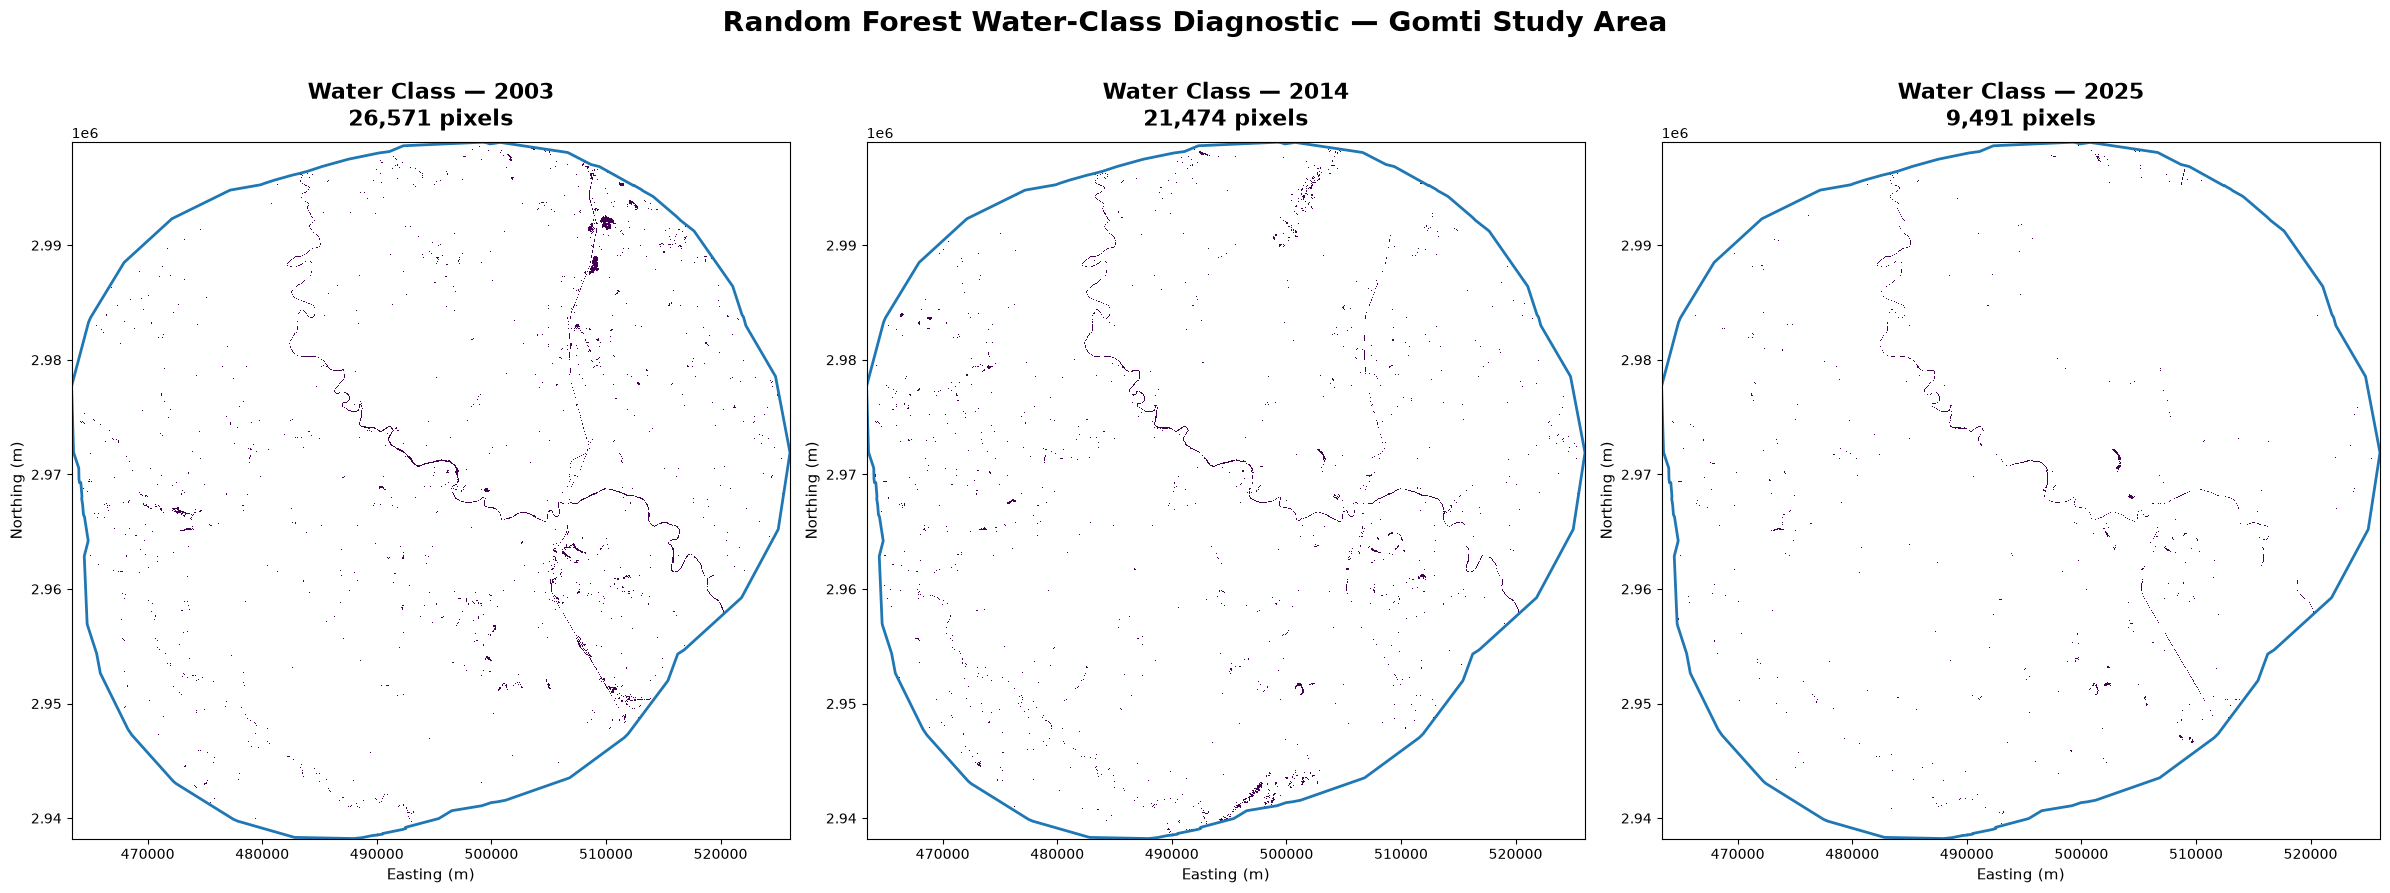


Saved: d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_04\LULC_RF_water_diagnostic_2003_2014_2025.png


In [142]:
# ============================================================
# Step 12.4 — Water-Class Diagnostic — Large Visualization
# ============================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Final LULC raster paths
# ------------------------------------------------------------

lulc_map_paths = {
    2003: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2003.tif",
    2014: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2014.tif",
    2025: PROJECT_ROOT / "outputs" / "lulc_maps" / "LULC_RF_2025.tif"
}

# ------------------------------------------------------------
# Create large figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 9)
)

for ax, year in zip(
    axes,
    [2003, 2014, 2025]
):

    path = lulc_map_paths[year]

    with rasterio.open(path) as src:

        lulc = src.read(1)

        # ----------------------------------------------------
        # Extract water class
        # ----------------------------------------------------

        water = np.where(
            lulc == 1,
            1,
            np.nan
        )

        water_pixels = np.count_nonzero(
            lulc == 1
        )

        # ----------------------------------------------------
        # Raster geographic extent
        # ----------------------------------------------------

        bounds = src.bounds

        extent = [
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]

        # ----------------------------------------------------
        # Plot water
        # ----------------------------------------------------

        ax.imshow(
            water,
            extent=extent,
            origin="upper",
            interpolation="none"
        )

        # ----------------------------------------------------
        # Study-area boundary
        # ----------------------------------------------------

        study_area_gdf.boundary.plot(
            ax=ax,
            linewidth=2
        )

        # ----------------------------------------------------
        # Use the study-area extent for display
        # ----------------------------------------------------

        study_bounds = study_area_gdf.total_bounds

        ax.set_xlim(
            study_bounds[0],
            study_bounds[2]
        )

        ax.set_ylim(
            study_bounds[1],
            study_bounds[3]
        )

        # ----------------------------------------------------
        # Title
        # ----------------------------------------------------

        ax.set_title(
            f"Water Class — {year}\n"
            f"{water_pixels:,} pixels",
            fontsize=16,
            fontweight="bold",
            pad=12
        )

        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        ax.set_xlabel(
            "Easting (m)",
            fontsize=11
        )

        ax.set_ylabel(
            "Northing (m)",
            fontsize=11
        )

        # ----------------------------------------------------
        # Equal geographic aspect
        # ----------------------------------------------------

        ax.set_aspect(
            "equal"
        )

# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Random Forest Water-Class Diagnostic — Gomti Study Area",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# ------------------------------------------------------------
# Tight layout
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_04"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

water_diagnostic_path = (
    FIGURES_DIR
    / "LULC_RF_water_diagnostic_2003_2014_2025.png"
)

fig.savefig(
    water_diagnostic_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSaved: {water_diagnostic_path}"
)